**Version 10.3** · 2026-07-27 09:20 BRT · git tag `v10.3`

# Deep Borehole Heat Exchanger (DBHE) — Coupled Facility Notebook
## Onshore South Louisiana Legacy Well · Insulated Tubing · Desiccant Cooling

**Purpose:** production solver for the DBHE-driven cooling application. A deep borehole
heat exchanger supplies hot water to a regeneration coil, which drives a rotary desiccant
wheel that dehumidifies the process air of a hatchery held at fixed comfort conditions.

**Layout**

- **Cell 0** — environment setup (installs `iapws`; required on Colab)
- **Cell 1** — imports
- **Cell 2** — configuration. *This is the only cell you need to edit.*
- **Cells 3–7** — auto-computed: geometry and conductances, fluid properties, convective
  correlations and NTU functions, GITT formation model, fluid BVP transfer-matrix solver
- **Cells 8–15** — component models: regeneration coil, DBHE block, thermal accumulator,
  pump and DBHE friction, desiccant wheel, regeneration air loop, building/process air
  loop, hatchery loads and air–air cooler
- **Cell 16** — coupled facility driver with hybrid building control
- **Cell 17** — results dashboard: runs the coupled facility, reports each subsystem vs. year
- **Cell 18** — psychrometric chart of the two air loops

**Water properties:** IAPWS-IF97 via the `iapws` package. There is deliberately **no
constant-property fallback** — if the library is missing the notebook raises an error
instead of silently returning properties evaluated at a single reference temperature.


## Cell 0 · Environment  *(run once per Colab session)*

In [1]:
# ---------------------------------------------------------------------------
# Notebook version stamp. Bump NB_VERSION and NB_STAMP together with the
# header line in the title cell above, and tag the commit v<NB_VERSION>.
# These strings are printed with the results and drawn on every figure, so
# any output can be traced back to the exact notebook that produced it.
NB_VERSION = "10.3"
NB_STAMP   = "2026-07-27 09:20 BRT"

def version_footer(fig=None):
    """Draw the version stamp in the bottom-right corner of a figure."""
    import matplotlib.pyplot as _plt
    (fig or _plt.gcf()).text(0.995, 0.003, f"v{NB_VERSION} · {NB_STAMP}",
                             ha="right", va="bottom", fontsize=6, color="0.55")
# ---------------------------------------------------------------------------

# Colab does not ship `iapws`. This installs it if missing and is a no-op locally.
try:
    import iapws  # noqa: F401
    print("iapws already present")
except ImportError:
    !pip install -q iapws
    import iapws  # noqa: F401
    print("iapws installed")

print(f"DBHE master notebook  v{NB_VERSION}  ({NB_STAMP})")


iapws already present
DBHE master notebook  v10.3  (2026-07-27 09:20 BRT)


## Cell 1 · Imports

In [2]:
# IAPWS-IF97 replaces CoolProp for water properties.
# Correlations: IAPWS-IF97 (liquid region, 0–374 C, 0–100 MPa)

import numpy as np
from scipy.special import j0, j1, y0, y1
from scipy.optimize import brentq
from scipy.linalg import expm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')            # silence noisy library warnings
warnings.simplefilter('always', UserWarning)  # ...but NEVER this notebook's own
                                              # diagnostics (warnings.warn defaults
                                              # to UserWarning). Without this line the
                                              # GITT non-positive-norm check below can
                                              # never fire.
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Water properties: IAPWS-IF97. Hard requirement -- no silent fallback.
# If this import fails, run Cell 0 above.
from iapws import IAPWS97
print("iapws OK")

print("Imports OK")


iapws OK
Imports OK


## Cell 2 · Configuration — ALL Parameters Here
**This is the only cell you need to edit.**


In [3]:
import numpy as np

# ============================================================
#  SECTION A — WELLBORE GEOMETRY
#  Representative onshore S. Louisiana legacy well
#  API 2-7/8 in tubing in 7 in production casing, 8.5 in hole
# ============================================================
rt_i  = 0.03099   # tubing inner radius [m]  -- 2.441 in ID
rt_o  = 0.03652   # tubing outer radius [m]  -- 2.875 in OD
rca_i = 0.07975   # casing inner radius [m]  -- 6.276 in ID (26 lb/ft)
rca_o = 0.08890   # casing outer radius [m]  -- 7.000 in OD
rce   = 0.10795   # cement outer radius [m]  -- 8.5 in hole

# ============================================================
#  SECTION B — MATERIAL THERMAL CONDUCTIVITIES
# ============================================================
kca          = 45.0   # casing steel [W/(m.K)]
kce          = 0.95   # Gulf Coast cement, silica-flour blend [W/(m.K)]
kt_bare      = 45.0   # bare steel tubing [W/(m.K)]  -- Case A
kt_insulated = 0.02   # vacuum-insulated tubing VIT [W/(m.K)]  -- Case B

# ============================================================
#  SECTION C — FORMATION PROPERTIES (Gulf Coast sedimentary)
# ============================================================
ke      = 2.2     # formation thermal conductivity [W/(m.K)]  (shale-dominant)
alpha_e = 1.05e-6 # formation thermal diffusivity [m^2/s]
T_surf  = 20.0    # mean annual surface temperature, S. Louisiana [C]
Gg      = 0.031    # geothermal gradient [K/m]  -- typical Gulf Coast

# ============================================================
#  SECTION D — OPERATING CONDITIONS
# ============================================================
Tin             = 25.0   # injection temperature [C]  (surface ambient)
P_op            = 50e5   # wellbore operating pressure [Pa]  (hydrostatic)
T_cement_limit  = 165.0  # Class G/H cement reliability limit [C]

# ============================================================
#  SECTION E — SUBSURFACE DUTY  (RETIRED — see note in Cell 9)
# ============================================================
# f_op no longer derates the GITT forcing: the subsurface runs CONTINUOUSLY and
# the duty cycle now lives in the SURFACE valve schedule (w_vA, w_vC, w_vE). Kept
# defined (=1.0) only so nothing that references it breaks. The paper's GITT
# f_op derating needs a corresponding amendment.
f_op = 1.00

# ============================================================
#  SECTION F — SIMULATION HORIZON
# ============================================================
n_years = 20   # simulation duration [years]

# ============================================================
#  SECTION G — NUMERICAL PARAMETERS
# ============================================================
NZ              = 50     # axial cells in fluid BVP (baseline)
Neig            = 60     # GITT eigenvalues, Set A (baseline)
n_days_per_step = 0.25   # time step [days] (baseline)

USE_QS_CORRECTION = False   # quasi-steady Set B correction (off for baseline)
Neig_B = 1200              # total modes for QS correction if enabled

# ============================================================
#  SECTION H — LiBr SINGLE-EFFECT ABSORPTION CHILLER
# ============================================================
T_cond     = 35.0    # condenser temperature [C]  (cooling tower, Gulf Coast summer)
T_evap     =  7.0    # evaporator temperature [C]  (chilled water supply)
T_abs      = 37.0    # absorber temperature [C]  (approx T_cond + 2)
a_char     =  0.395  # characteristic equation intercept (Ziegler & Treeck fit)
b_char     =  0.00315 # characteristic equation slope [1/K]
f_char     =  1.00   # characteristic equation factor
T_libr_min = 78.0    # minimum viable generator temperature [C]
T_libr_max = 110.0   # maximum generator temperature [C]  (crystallisation risk)

# ============================================================
#  SECTION I — DEMO / DEFAULT OPERATING POINT
# ============================================================
Lbh_default        = 4500.   # depth for demo run and convergence study [m]
flow_rate_m3_h_demo = 10.    # LOOP volumetric flow (fixed by pump) [m3/h]; well flow = w_vE * this
kt_demo             = kt_insulated  # insulated tubing for convergence focus

# ============================================================
#  SECTION J — REGENERATION COIL / AIR-SIDE PARAMETERS
# ============================================================
CP_A     = 1006.0   # regeneration air specific heat [J/(kg K)]
ua_coil_per_kgs = 3000.0  # coil UA per kg/s of regen air [W/K / (kg/s)] -> NTU ~ 3 (UA_coil derived in S)

# ============================================================
#  SECTION K — HYDRAULIC CIRCUIT  (valve split fractions)
# ============================================================
w_vA = 0.30   # fraction of WELL flow sent to the ACC branch (A);  w_vB = 1 - w_vA to coil branch (B)
w_vC = 0.50   # fraction of ACC-outlet flow returned to the COIL inlet (C); w_vD = 1 - w_vC to reinjection (D)
w_vE = 1.00   # fraction of LOOP flow sent DOWN THE WELL (E); w_vF = 1 - w_vE bypasses the well
w_vE_min = 0.05  # floor on w_vE (keep a trickle circulating rather than a true shutdown)

# ============================================================
#  SECTION L — THERMAL ACCUMULATOR  (sand/concrete box or water tank)
# ============================================================
V_acc       = 2000.0   # accumulator volume [m3]
rho_acc     = 1600.0   # storage-medium density [kg/m3]   (packed sand ~1600; water 1000)
cp_acc      = 830.0    # storage-medium specific heat [J/(kg K)]  (sand ~830; water 4180)
eps_acc     = 0.70     # ACC charge/discharge heat-exchange effectiveness [-]
UA_acc_loss = 150.0    # ACC heat-loss conductance to surroundings [W/K]
# T_acc_amb is set = T_oa further below (accumulator loses to outdoor air)
T_acc_init  = 25.0     # initial accumulator temperature [C]

# ============================================================
#  SECTION M — PUMP / HYDRAULICS
# ============================================================
eta_pump = 0.65   # pump overall (wire-to-water) efficiency [-]

# ============================================================
#  SECTION N — LOOP SOLVER  (closed-loop fixed point)
# ============================================================
fp_tol = 1e-4   # loop-temperature fixed-point tolerance [C]
fp_max = 40     # max fixed-point iterations per time step

# ============================================================
#  SECTION O — DESICCANT WHEEL  (Jurinak F1/F2)
# ============================================================
eta_F1 = 0.10   # characteristic-potential effectiveness (enthalpy-like) [-]  <- FIT to wheel data
eta_F2 = 0.70   # characteristic-potential effectiveness (RH-like)       [-]  <- FIT to wheel data

# ============================================================
#  SECTION P — REGENERATION AIR LOOP  (dampers, flows, external air)
# ============================================================
d_rA          = 0.30   # regen-air VENT fraction to environment (A); d_rB = 1 - d_rA recirculated (B)
                     # makeup fresh air (damper C) = vented mass (mass balance): rC-flow = d_rA-flow
rho_da      = 1.20   # dry-air density for volume<->mass conversion [kg/m3]
p_atm       = 101325.0  # atmospheric pressure [Pa]  (all psychrometrics routed through this)
T_oa   = 31.0   # external (ambient) air temperature [C]  (Gulf design day)
RH_oa  = 0.75   # external (ambient) air relative humidity [-] (Gulf design day)
dT_fan      = 0.0    # supply-fan temperature rise [C]  (isenthalpic for now; add fan heat later)

# ============================================================
#  SECTION Q — BUILDING & PROCESS AIR LOOP  (prescribed comfort; loads computed)
# ============================================================
T_pc        = 37.0   # building comfort temperature [C]   (hatchery setter)
RH_pc       = 0.50   # building comfort relative humidity [-] (hatchery)
dT_supply_design = 3.0   # DESIGN supply depression below room, T_pc - T_pi [K]
                         #   setters run high recirculation / small dT (do not chill eggs unevenly)
                         #   -> sets mdot_pro; d_pA is then DERIVED in Section S (NOT prescribed)
dT_fan_pro  = 0.0    # process supply-fan temperature rise [C] (isenthalpic for now)


# ============================================================
#  SECTION S — HATCHERY SIZING  (EVERYTHING derived from N_eggs)
# ============================================================
N_eggs        = 1000000  # eggs in incubation (large industrial hatchery)
# --- per-egg / geometric coefficients (PLACEHOLDERS: fit to strain & machine data) ---
q_egg_sens    = 0.13     # embryonic + equipment SENSIBLE heat [W/egg] (avg; ~0.15 near hatch)
rate_evap_egg = 4.6e-9   # egg MOISTURE loss [kg/s/egg] (~0.4 g/egg/day; 12% over 18 d)
vent_per_egg  = 0.030    # fresh-air ventilation requirement [m3/h/egg]
eggs_per_m2   = 200.0    # floor packing incl. aisles [eggs/m2]
room_height   = 3.5      # room height [m]
U_env         = 0.5      # envelope overall U-value [W/(m2 K)]
ACH_inf       = 0.5      # infiltration air changes per hour [1/h]
reg_pro_ratio = 0.70     # regeneration / process air flow ratio [-]
dT_solar      = 4.0      # sol-air adder: T_solair = T_oa + dT_solar [C]
h_fg_load     = 2.5e6    # latent heat for load calcs [J/kg]
# --- derived internal loads (proportional to N_eggs) ---
Q_eggs_sens    = N_eggs * q_egg_sens                 # [W]
mdot_evap_eggs = N_eggs * rate_evap_egg              # [kg/s]
# --- derived geometry (floor & roof ~ N_eggs; walls ~ sqrt(floor)) ---
A_floor  = N_eggs / eggs_per_m2                       # [m2]
V_room   = A_floor * room_height                      # [m3]
A_walls  = 4.0 * np.sqrt(A_floor) * room_height       # [m2] (square footprint)
H_tr     = U_env * (2.0*A_floor + A_walls)            # [W/K] roof+floor+walls
mdot_inf = rho_da * V_room * ACH_inf / 3600.          # [kg/s]
# --- derived airflows -------------------------------------------------------
#  CAUSALITY: the SENSIBLE load sets the supply flow at the design dT; the FORCED
#  ventilation (CO2/O2, set by the eggs) is a LOWER BOUND on it; the fresh-air
#  damper d_pA is then DERIVED, opening only as far as ventilation requires.
#  (Prescribing d_pA and writing mdot_pro = mdot_vent/d_pA inverts this and makes
#   the fan flow blow up as 1/d_pA -- an artifact, not physics.)
mdot_vent      = rho_da * (N_eggs*vent_per_egg) / 3600.   # FORCED fresh air [kg/s]
T_solair_dsg   = T_oa + dT_solar
Q_sens_design  = (Q_eggs_sens + H_tr*(T_solair_dsg - T_pc)
                  + mdot_inf*CP_A*(T_oa - T_pc))          # design sensible load [W]
mdot_pro_load  = max(Q_sens_design, 0.) / (CP_A*dT_supply_design)   # flow to carry it at design dT
mdot_pro       = max(mdot_pro_load, mdot_vent)            # ventilation is a floor [kg/s]
d_pA           = min(mdot_vent/mdot_pro, 1.0)             # DERIVED fresh-air damper; d_pB = 1 - d_pA
vent_dominated = mdot_pro_load <= mdot_vent               # True -> 100% once-through, no recirculation
dT_supply_act  = max(Q_sens_design, 0.)/(mdot_pro*CP_A)   # dT actually achieved [K]
mdot_reg       = reg_pro_ratio * mdot_pro                  # regeneration air flow [kg/s]
UA_coil        = ua_coil_per_kgs * mdot_reg                # coil sized to the regen stream [W/K]
V_pro_m3h = mdot_pro/rho_da*3600.; V_reg_m3h = mdot_reg/rho_da*3600.

# ============================================================
#  SECTION T — AIR-AIR COOLER  (sensible; epsilon-NTU; rejects to ambient)
# ============================================================
cool_pro_ratio = 1.5     # cooler coolant / process air flow ratio [-]
mdot_cool      = cool_pro_ratio * mdot_pro   # cooler coolant (ambient) air flow [kg/s] (scales with plant)
UA_cool_max    = 1.5e5   # ceiling on cooler UA for the back-solve [W/K]

# ============================================================
#  SECTION U — BUILDING CONTROL  (hybrid: cooler UA for T, d_rA for humidity)
# ============================================================
d_rA_min         = 0.05    # floor on regen vent fraction (humidity knob lower bound)
w_ctrl_tol     = 1.0e-4  # humidity back-solve tolerance [kg/kg]
d_rA_ctrl_max_it = 12      # max outer iterations for the d_rA back-solve

T_acc_amb = T_oa   # accumulator loses heat to the outdoor air

# ── DERIVED CONSTANTS  (computed from above -- do not edit) ──────────────
t_day    = 86400.
dt_step  = n_days_per_step * t_day
n_steps  = int(n_years * 365.25 / n_days_per_step)

delta_20yr = np.sqrt(4. * alpha_e * n_years * 365.25 * t_day)
Rfar       = max(200., 3.5 * delta_20yr)   # far-field radius for GITT [m]

# ── Configuration summary ─────────────────────────────────────────────────
print('=' * 52)
print('  DBHE FACILITY MODEL — CONFIGURATION')
print('=' * 52)
print(f'  Depth (demo)    : {Lbh_default:.0f} m')
print(f'  BHT undisturbed : {T_surf + Gg*Lbh_default:.1f} C')
print(f'  Geothermal grad : {Gg*1000:.1f} mK/m')
print(f'  Injection temp  : {Tin:.1f} C')
print(f'  Simulation      : {n_years} yr  ({n_steps} baseline steps)')
print(f'  GITT Rfar       : {Rfar:.0f} m  (20-yr delta = {delta_20yr:.1f} m)')
print(f'  Baseline NZ / Neig / dt : {NZ} / {Neig} / {n_days_per_step} days')
print(f'  Valves          : w_vA={w_vA:.2f} w_vC={w_vC:.2f} w_vE={w_vE:.2f}')
print(f'  Subsurface duty : continuous (f_op retired to surface control)')
print(f'  Desiccant wheel : eta_F1={eta_F1:.2f}, eta_F2={eta_F2:.2f}')
print(f'  Hatchery        : N_eggs={N_eggs:,} -> A_floor={A_floor:.0f} m2, V_room={V_room:.0f} m3')
print(f'  Design sensible : {Q_sens_design/1e3:.1f} kW @ dT_supply={dT_supply_act:.1f} K'
      f"  ->  supply {mdot_pro:.1f} kg/s ({V_pro_m3h:,.0f} m3/h)")
print(f'  Forced vent     : {mdot_vent:.1f} kg/s -> d_pA={d_pA:.3f} (derived)'
      f"{'  [VENTILATION-DOMINATED: 100% once-through]' if vent_dominated else ''}")
print(f'  Regen / cooler  : {mdot_reg:.1f} / {mdot_cool:.1f} kg/s | UA_coil={UA_coil/1e3:.1f} kW/K')
print(f'  Comfort         : {T_pc:.0f} C / {RH_pc:.0%} RH   |  ambient {T_oa:.0f} C / {RH_oa:.0%} RH')
print(f'  Accumulator     : {V_acc:.0f} m3, C_acc = {rho_acc*cp_acc*V_acc/1e9:.2f} GJ/K, eps={eps_acc:.2f}')
print(f'  LiBr params     : {T_libr_min:.0f} - {T_libr_max:.0f} C  (chiller block not active)')

  DBHE FACILITY MODEL — CONFIGURATION
  Depth (demo)    : 4500 m
  BHT undisturbed : 159.5 C
  Geothermal grad : 31.0 mK/m
  Injection temp  : 25.0 C
  Simulation      : 20 yr  (29220 baseline steps)
  GITT Rfar       : 200 m  (20-yr delta = 51.5 m)
  Baseline NZ / Neig / dt : 50 / 60 / 0.25 days
  Valves          : w_vA=0.30 w_vC=0.50 w_vE=1.00
  Subsurface duty : continuous (f_op retired to surface control)
  Desiccant wheel : eta_F1=0.10, eta_F2=0.70
  Hatchery        : N_eggs=1,000,000 -> A_floor=5000 m2, V_room=17500 m3
  Design sensible : 101.4 kW @ dT_supply=3.0 K  ->  supply 33.6 kg/s (100,800 m3/h)
  Forced vent     : 10.0 kg/s -> d_pA=0.298 (derived)
  Regen / cooler  : 23.5 / 50.4 kg/s | UA_coil=70.6 kW/K
  Comfort         : 37 C / 50% RH   |  ambient 31 C / 75% RH
  Accumulator     : 2000 m3, C_acc = 2.66 GJ/K, eps=0.70
  LiBr params     : 78 - 110 C  (chiller block not active)


## Cell 3 · Geometry and Conductances  *(auto-computed)*

In [4]:
# Derived from Section A and B — do not edit here
Aa    = np.pi * (rca_i**2 - rt_o**2)
Atb   = np.pi * rt_i**2
Dh_a  = 2. * (rca_i - rt_o)
Dh_tb = 2. * rt_i

# Log-mean (thermodynamic centroid) radii  -- Eq. r_logmean
rlm_t  = (rt_o  - rt_i)  / np.log(rt_o  / rt_i)   # tubing wall centroid
rlm_ca = (rca_o - rca_i) / np.log(rca_o / rca_i)  # casing wall centroid
rlm_ce = (rce   - rca_o) / np.log(rce   / rca_o)  # cement annulus centroid
rlm    = rlm_t   # backward-compat alias (used in BVP sanity check)

# Gext: pure conduction through casing + cement (used ONLY for cement
# temperature check and alpha/beta_cao -- NOT fed into NTU calculation)
R_ca  = np.log(rca_o / rca_i) / (2. * np.pi * kca)
R_ce  = np.log(rce   / rca_o) / (2. * np.pi * kce)
Gext  = 1.0 / (R_ca + R_ce)

alpha_cao = 1.0 - Gext * R_ca
beta_cao  =       Gext * R_ca

print(f"Annulus area   Aa    = {Aa:.4e} m^2")
print(f"Tubing  area   Atb   = {Atb:.4e} m^2")
print(f"Hydraulic Dh_a       = {Dh_a*100:.2f} cm   Dh_tb = {Dh_tb*100:.2f} cm")
print(f"Log-mean radii [mm]  : rlm_t={rlm_t*1e3:.3f}  rlm_ca={rlm_ca*1e3:.3f}  rlm_ce={rlm_ce*1e3:.3f}")
print(f"Gext (cond only)     = {Gext:.4f} W/(m.K)  [used for cement T-check only]")
T_cao_check = alpha_cao * (T_surf + Gg*Lbh_default) + beta_cao * 60.
print(f"Cement wall T check  : {T_cao_check:.1f} C "
      + ("(OK)" if T_cao_check < T_cement_limit else "(EXCEEDS LIMIT)"))


Annulus area   Aa    = 1.5791e-02 m^2
Tubing  area   Atb   = 3.0171e-03 m^2
Hydraulic Dh_a       = 8.65 cm   Dh_tb = 6.20 cm
Log-mean radii [mm]  : rlm_t=33.679  rlm_ca=84.242  rlm_ce=98.117
Gext (cond only)     = 30.3846 W/(m.K)  [used for cement T-check only]
Cement wall T check  : 158.3 C (OK)


## Cell 4 · Fluid Properties  *(auto-computed)*

In [5]:
# Water properties via IAPWS-IF97 (replaces CoolProp)
# Valid: compressed liquid, 0–374 C, 0–100 MPa.
# For P_op=50 bar the saturation temperature is ~264 C, so liquid phase
# is guaranteed for all temperatures encountered in this wellbore model.

def water_props(T_C, P_Pa=P_op):
    # No constant-property fallback: a fixed 70 C estimate misstates mu and Pr by
    # ~-38% at 43 C and ~+90% at 130 C, both of which feed Gnielinski directly.
    P_MPa = P_Pa / 1e6
    w = IAPWS97(T=T_C + 273.15, P=P_MPa)
    return {
        'rho': w.rho,
        'cp' : w.cp * 1e3,     # IAPWS returns kJ/(kg·K) -> J/(kg·K)
        'mu' : w.mu,
        'kf' : w.k,
        'Pr' : w.Prandt,
    }

T_mean_est = min((Tin + T_surf + Gg * Lbh_default * 0.6) / 2., 95.)
props_ref   = water_props(T_mean_est)

print(f"Reference fluid properties at T = {T_mean_est:.1f} C  (IAPWS-IF97):")
for k, v in props_ref.items():
    print(f"  {k:5s} = {v:.4g}")

w_sat = IAPWS97(T=160. + 273.15, x=0.)
print(f"Sat. pressure at 160 C = {w_sat.P*10:.2f} bar  "
      f"(P_op = {P_op/1e5:.0f} bar -> liquid OK)")


Reference fluid properties at T = 64.3 C  (IAPWS-IF97):
  rho   = 983
  cp    = 4174
  mu    = 0.0004382
  kf    = 0.6576
  Pr    = 2.782
Sat. pressure at 160 C = 6.18 bar  (P_op = 50 bar -> liquid OK)


## Cell 5 · Convective Correlations and NTU Functions  *(auto-computed)*

In [6]:
def gnielinski_h(v, Dh, props, Re_clamp=3100.):
    Re = props['rho'] * max(abs(v), 1e-9) * Dh / props['mu']
    Re = max(Re, Re_clamp)
    fD = (0.790 * np.log(Re) - 1.64) ** (-2)
    Nu = (fD/8.) * (Re - 1000.) * props['Pr'] / (
         1. + 12.7 * np.sqrt(fD/8.) * (props['Pr']**(2./3.) - 1.))
    return Nu * props['kf'] / Dh


def compute_NTUs(Q_m3_h, Lbh, props, kt):
    # ── mass flow rates ───────────────────────────────────────────────────
    Q_a = Q_m3_h / 3600. # Convert m3/h to m3/s
    va = Q_a / Aa
    mdot_a = props['rho'] * Q_a
    vtb    = va * Aa / Atb

    # ── convective film coefficients ──────────────────────────────────────
    ha  = gnielinski_h(va,  Dh_a,  props)   # annulus side
    htb = gnielinski_h(vtb, Dh_tb, props)   # tubing bore side

    # ── G_a,t : annulus film + outer half of tubing wall ─────────────────
    # Eq. G_at:  [ln(r_to/r̄_t)/(2π k_t)  +  1/(2π r_to h_a)]^{-1}
    G_at = 1.0 / (  np.log(rt_o / rlm_t) / (2.*np.pi*kt)
                  + 1.0 / (2.*np.pi*rt_o*ha)  )

    # ── G_tb,t : inner half of tubing wall + tubing-bore film ─────────────
    # Eq. G_tbt: [1/(2π r_ti h_tb)  +  ln(r̄_t/r_ti)/(2π k_t)]^{-1}
    G_tbt = 1.0 / (  1.0 / (2.*np.pi*rt_i*htb)
                   + np.log(rlm_t / rt_i) / (2.*np.pi*kt)  )

    # ── NTU_eff_a,tb : series combination ─────────────────────────────────
    # Eq. NTU_eff_at = [1/G_at + 1/G_tbt]^{-1} * L / (mdot cp)
    G_eff_at  = 1.0 / (1.0/G_at + 1.0/G_tbt)
    NTUeff_at = G_eff_at * Lbh / (mdot_a * props['cp'])

    # ── G_a,ca : annulus film + inner half of casing wall ─────────────────
    # Eq. G_aca: [1/(2π r_cai h_a)  +  ln(r̄_ca/r_cai)/(2π k_ca)]^{-1}
    G_aca = 1.0 / (  1.0 / (2.*np.pi*rca_i*ha)
                   + np.log(rlm_ca / rca_i) / (2.*np.pi*kca)  )

    # ── G_ca,ce : outer half of casing wall + inner half of cement ────────
    # Eq. G_cace: [ln(r_cao/r̄_ca)/(2π k_ca)
    #              + ln(r̄_ce/r_cao)/(2π k_ce)]^{-1}
    G_cace = 1.0 / (  np.log(rca_o / rlm_ca) / (2.*np.pi*kca)
                    + np.log(rlm_ce / rca_o)  / (2.*np.pi*kce)  )

    # ── G_ce : outer half of cement to borehole wall ──────────────────────
    # Eq. G_ce:  2π k_ce / ln(r_ce / r̄_ce)
    G_ce = 2.*np.pi*kce / np.log(rce / rlm_ce)

    # ── NTU_eff_a,ce : full series chain a -> ca -> ce -> bw ──────────────
    # Eq. NTU_eff_ace = [1/G_aca + 1/G_cace + 1/G_ce]^{-1} * L/(mdot cp)
    G_eff_ace = 1.0 / (1.0/G_aca + 1.0/G_cace + 1.0/G_ce)
    NTUa_bw   = G_eff_ace * Lbh / (mdot_a * props['cp'])

    return NTUeff_at, NTUa_bw, mdot_a, va, vtb


print(f"NTU comparison at Lbh = {Lbh_default:.0f} m, Flow rate = {flow_rate_m3_h_demo:.1f} m3/h:")
print(f"{'Case':<20} {'NTUat':>8} {'NTUbw':>8}  Note")
print("-" * 62)
for lbl, kt in [('Case A: Bare', kt_bare), ('Case B: Insulated', kt_insulated)]:
    at, bw, mdot, va, vtb = compute_NTUs(flow_rate_m3_h_demo, Lbh_default, props_ref, kt)
    note = 'Short-circuit significant' if at > 1. else 'Short-circuit suppressed'
    print(f"{lbl:<20} {at:>8.3f} {bw:>8.3f}  {note}")

NTU comparison at Lbh = 4500 m, Flow rate = 10.0 m3/h:
Case                    NTUat    NTUbw  Note
--------------------------------------------------------------
Case A: Bare           75.851   11.421  Short-circuit significant
Case B: Insulated       0.301   11.421  Short-circuit suppressed


## Cell 6 · GITT Formation Model  *(auto-computed)*

In [7]:
def _get_gitt_arrays(neig_val, r_ce_val, R_far_val, ke_val, alpha_e_val, dt_step_val):
    # Local definitions to handle parameter passing for R_far_val and r_ce_val
    def gitt_char_eq_local(beta):
        return y1(beta * r_ce_val) * j0(beta * R_far_val) - j1(beta * r_ce_val) * y0(beta * R_far_val)

    def compute_eigenvalues_local(n_eig_local, beta_max=200., n_scan=800_000):
        betas = np.linspace(1e-6, beta_max, n_scan)
        fvals = np.vectorize(gitt_char_eq_local)(betas)
        roots = []
        for i in range(len(betas)-1):
            if fvals[i] * fvals[i+1] < 0.:
                root = brentq(gitt_char_eq_local, betas[i], betas[i+1], xtol=1e-14)
                roots.append(root)
                if len(roots) == n_eig_local:
                    break
        if len(roots) < n_eig_local:
            raise ValueError(f"Only {len(roots)}/{n_eig_local} eigenvalues found for Rfar={R_far_val}.")
        return np.array(roots)

    def psi_local(beta, r):
        return y1(beta * r_ce_val) * j0(beta * r) - j1(beta * r_ce_val) * y0(beta * r)

    def compute_norms_local(betas_local, Nr_base=6000):
        norms = np.zeros(len(betas_local))
        for i, b in enumerate(betas_local):
            half_wavelength = np.pi / b
            Nr_needed = max(Nr_base, int(20. * (R_far_val - r_ce_val) / half_wavelength))
            r = np.linspace(r_ce_val, R_far_val, Nr_needed)
            norms[i] = np.trapezoid(r * psi_local(b, r)**2, r)
        return norms


    betas_arr_local  = compute_eigenvalues_local(neig_val)
    norms_arr_local  = compute_norms_local(betas_arr_local)

    # Sanity check for norms
    bad_norms = np.where(norms_arr_local <= 0.)[0]
    if len(bad_norms) > 0:
        warnings.warn(
            f"Non-positive norms at modes {bad_norms + 1} -- "
            f"increase Nr_base in compute_norms or reduce Neig ({neig_val})."
        )

    psi_rce_local    = psi_local(betas_arr_local, r_ce_val)
    inv_wts_local    = psi_rce_local / norms_arr_local
    forc_coeff_local = psi_rce_local / (2. * np.pi * ke_val * betas_arr_local**2)
    tau_arr_local    = 1. / (alpha_e_val * betas_arr_local**2)
    decay_step_local = np.exp(-alpha_e_val * betas_arr_local**2 * dt_step_val)

    return betas_arr_local, norms_arr_local, psi_rce_local, inv_wts_local, forc_coeff_local, tau_arr_local, decay_step_local

# These global functions are kept for compatibility/potential external use. However,
# run_dbhe and run_dbhe_app now use _get_gitt_arrays for their parameter generation.
def gitt_char_eq(beta):
    return y1(beta*rce)*j0(beta*Rfar) - j1(beta*rce)*y0(beta*Rfar)

def compute_eigenvalues(n_eig, beta_max=200., n_scan=800_000):
    betas = np.linspace(1e-6, beta_max, n_scan)
    fvals = np.vectorize(gitt_char_eq)(betas)
    roots = []
    for i in range(len(betas)-1):
        if fvals[i] * fvals[i+1] < 0.:
            root = brentq(gitt_char_eq, betas[i], betas[i+1], xtol=1e-14)
            roots.append(root)
            if len(roots) == n_eig:
                break
    if len(roots) < n_eig:
        raise ValueError(f"Only {len(roots)}/{n_eig} eigenvalues found.")
    return np.array(roots)

def psi(beta, r):
    return y1(beta*rce)*j0(beta*r) - j1(beta*rce)*y0(beta*r)

def compute_norms(betas, Nr_base=6000):
    norms = np.zeros(len(betas))
    for i, b in enumerate(betas):
        half_wavelength = np.pi / b
        Nr_needed = max(Nr_base, int(20. * (Rfar - rce) / half_wavelength))
        r = np.linspace(rce, Rfar, Nr_needed)
        norms[i] = np.trapezoid(r * psi(b, r)**2, r)
    return norms

print("GITT setup functions defined.")

# ── Pre-compute quasi-steady Set B correction coefficient C_B ─────────────
# C_B = sum_{n=Neig+1}^{Neig_B} psi_n(rce)^2 / (beta_n^2 * norm_n) / (2*pi*ke)
# Evaluated once here; used every timestep in run_dbhe if USE_QS_CORRECTION=True.
if USE_QS_CORRECTION and Neig_B > Neig:
    print(f"  Computing Set B eigenvalues (n={Neig+1} to {Neig_B}) for QS correction...",
          end=" ", flush=True)
    (betas_B_arr, norms_B_arr, psi_rce_B_arr, _, _, tau_B_arr, _) = _get_gitt_arrays(
        Neig_B, rce, Rfar, ke, alpha_e, dt_step)
    # Isolate Set B portion (modes Neig+1 through Neig_B)
    betas_B   = betas_B_arr[Neig:]
    norms_B   = norms_B_arr[Neig:]
    psi_rce_B = psi_rce_B_arr[Neig:]
    tau_B     = tau_B_arr[Neig:]
    decay_B   = np.exp(-alpha_e * betas_B**2 * dt_step)
    # C_B: quasi-steady thermal resistance contribution of Set B [K·m/W]
    C_B = np.sum(psi_rce_B**2 / (betas_B**2 * norms_B)) / (2. * np.pi * ke)
    print(f"done.")
    print(f"  C_B = {C_B:.6f} K·m/W  ({100*C_B/np.log(Rfar/rce)*(2.*np.pi*ke):.1f}% of R_ss)")
    print(f"  Fastest Set B mode: tau = {tau_B[-1]/3600.:.2f} h  "
          f"decay = {decay_B[-1]:.4f}")
    print(f"  Slowest Set B mode: tau = {tau_B[0]/3600.:.1f} h  "
          f"decay = {decay_B[0]:.4f}")
else:
    C_B = 0.0
    betas_B = norms_B = psi_rce_B = tau_B = np.array([])
    if not USE_QS_CORRECTION:
        print("  QS correction DISABLED (USE_QS_CORRECTION=False)")
    else:
        print("  QS correction skipped (Neig_B <= Neig)")

GITT setup functions defined.
  QS correction DISABLED (USE_QS_CORRECTION=False)


## Cell 7 · Fluid BVP — Transfer Matrix Solver  *(auto-computed)*

In [8]:
def build_Phi_Psi(NTUeff_at, NTUa_bw, dz_star):
    A   = np.array([[-(NTUeff_at + NTUa_bw),  NTUeff_at],
                    [-NTUeff_at,                NTUeff_at]])
    Phi = expm(A * dz_star)
    Psi = np.linalg.solve(A, Phi - np.eye(2))
    return Phi, Psi


def solve_dbhe_bvp(NTUeff_at, NTUa_bw, theta_bw_cc, NZ_param, theta_a_in=0.):
    dz       = 1. / NZ_param
    Phi, Psi = build_Phi_Psi(NTUeff_at, NTUa_bw, dz)
    yH = np.zeros((NZ_param+1, 2));  yH[0] = [0., 1.]
    yP = np.zeros((NZ_param+1, 2));  yP[0] = [theta_a_in, 0.]
    for k in range(NZ_param):
        b_k     = np.array([NTUa_bw * theta_bw_cc[k], 0.])
        yH[k+1] = Phi @ yH[k]
        yP[k+1] = Phi @ yP[k] + Psi @ b_k
    s     = (yP[NZ_param,1] - yP[NZ_param,0]) / (yH[NZ_param,0] - yH[NZ_param,1])
    theta = s * yH + yP
    return theta[:,0], theta[:,1]


## Cell 8 · Regeneration Coil Equation  *(model)*
Liquid-to-air heating coil (ε-NTU, sensible). The DBHE return water `T_ret` heats the regeneration air from `T_air_in` up to the delivered regeneration temperature `T_reg`. **Open loop:** injection stays fixed at `Tin`; the coil is a downstream consumer of `T_ret` and does not feed back into the well.

In [9]:
def regen_coil(T_hw_in, mdot_hw, cp_hw, T_a_in, mdot_a, UA,
               arrangement="crossflow_unmixed"):
    """epsilon-NTU liquid->air heating coil (sensible only).
    Hot side = DBHE return water; cold side = regeneration air.

    Returns: Q [W], T_reg (air outlet -> desiccant wheel) [C],
             T_hw_out (water outlet) [C], eps [-].
    """
    C_hot  = mdot_hw * cp_hw
    C_cold = mdot_a  * CP_A
    Cmin, Cmax = min(C_hot, C_cold), max(C_hot, C_cold)
    Cr, NTU = Cmin / Cmax, UA / Cmin
    if arrangement == "crossflow_unmixed":            # both fluids unmixed (finned coil)
        eps = 1.0 - np.exp((1.0/Cr) * NTU**0.22 * (np.exp(-Cr*NTU**0.78) - 1.0))
    elif arrangement == "counterflow":
        eps = (NTU/(1.0+NTU) if Cr >= 1.0 else
               (1-np.exp(-NTU*(1-Cr)))/(1-Cr*np.exp(-NTU*(1-Cr))))
    else:
        raise ValueError(arrangement)
    Q = eps * Cmin * (T_hw_in - T_a_in)
    return Q, T_a_in + Q/C_cold, T_hw_in - Q/C_hot, eps

# quick check of the coil across water inlet temperature
print("Coil check (air=2 kg/s @ 30 C, UA=8 kW/K, water 2.7 kg/s):")
for Tw in (70., 85., 100., 115.):
    Q, Treg, Thw, eps = regen_coil(Tw, 2.7, 4174., 30., 2.0, 8000.)
    print(f"  T_ret={Tw:5.1f} C -> T_reg={Treg:5.1f} C, Q={Q/1e3:5.1f} kW, eps={eps:.3f}")

Coil check (air=2 kg/s @ 30 C, UA=8 kW/K, water 2.7 kg/s):
  T_ret= 70.0 C -> T_reg= 68.2 C, Q= 76.8 kW, eps=0.955
  T_ret= 85.0 C -> T_reg= 82.5 C, Q=105.6 kW, eps=0.955
  T_ret=100.0 C -> T_reg= 96.8 C, Q=134.5 kW, eps=0.955
  T_ret=115.0 C -> T_reg=111.2 C, Q=163.3 kW, eps=0.955


## Cell 9 · DBHE Model  *(block: init / set_flow / eval / advance)*
The well is now driven at the **well flow** `w_vE·ṁ`, refreshed each step by `dbhe_set_flow` (ready for a time-varying `w_vE`), which also **flags low Reynolds number** against Gnielinski's limit. `dbhe_eval` returns the produced temperature `T_ret`; `dbhe_advance` marches the GITT with the **continuous** flux — `f_op` has been retired from the subsurface (see the code note; paper amendment needed).

In [10]:
def T_inf_z(z_arr):
    return T_surf + Gg * z_arr

def dbhe_init(Lbh, loop_flow_m3_h, kt, nz=NZ, neig=Neig):
    """Build the flow-INDEPENDENT formation state (GITT eigenmodes, tail, Tbw).
    Flow-dependent well terms are set separately by dbhe_set_flow (ready for a
    time-varying w_vE)."""
    T_mean = min((Tin + T_surf + Gg * Lbh * 0.6) / 2., 95.)
    pr = water_props(T_mean)
    (betas, norms, psi_rce, inv_wts, forc, tau, decay) = _get_gitt_arrays(
        neig, rce, Rfar, ke, alpha_e, dt_step)
    R_ss   = np.log(Rfar / rce) / (2.*np.pi*ke)
    R_tail = R_ss - np.sum(psi_rce**2 / (betas**2 * norms)) / (2.*np.pi*ke)
    decay_tail = np.exp(-alpha_e * (betas[-1] + np.pi/Rfar)**2 * dt_step)
    z_cc = (np.arange(nz) + 0.5) * (Lbh/nz)
    st = dict(Lbh=Lbh, kt=kt, nz=nz, pr=pr, cp_w=pr['cp'],
              loop_flow=loop_flow_m3_h, mdot_loop=pr['rho']*loop_flow_m3_h/3600.,
              inv_wts=inv_wts, forc=forc, decay=decay, R_tail=R_tail, R_ss=R_ss,
              decay_tail=decay_tail, z_cc=z_cc,
              U_bar=np.zeros((nz, neig)), U_tail=np.zeros(nz), Tbw=T_inf_z(z_cc).copy(),
              label='Bare' if kt > 1. else 'Insulated', _re_warned=False)
    dbhe_set_flow(st, 1.0)                       # default: full well flow
    return st

def dbhe_set_flow(st, w_vE):
    """(Re)compute the flow-DEPENDENT well terms at the current well flow = w_vE*loop_flow.
    Cheap -- safe to call every step when w_vE varies in time. Flags low Reynolds number."""
    w_vE_eff   = max(w_vE, 1e-6)
    well_flow = w_vE_eff * st['loop_flow']
    NTUat, NTUbw, mdot_well, va, vtb = compute_NTUs(well_flow, st['Lbh'], st['pr'], st['kt'])
    st['w_vE_active'] = w_vE_eff
    st['NTUat']=NTUat; st['NTUbw']=NTUbw; st['mdot_well']=mdot_well; st['va']=va; st['vtb']=vtb
    st['G_eff_ace'] = NTUbw * mdot_well * st['pr']['cp'] / st['Lbh']
    # --- Gnielinski validity flag (correlation valid Re>~3000; gnielinski_h clamps at 3100) ---
    Re_a = st['pr']['rho']*abs(va)*Dh_a /st['pr']['mu']
    Re_t = st['pr']['rho']*abs(vtb)*Dh_tb/st['pr']['mu']
    st['Re_annulus']=Re_a; st['Re_tubing']=Re_t
    if (Re_a < 3000. or Re_t < 3000.) and not st['_re_warned']:
        print(f"  [!] Gnielinski Re-limit hit: w_vE={w_vE_eff:.3f} -> Re_ann={Re_a:.0f}, "
              f"Re_tub={Re_t:.0f} (<3000: film coefficient approximate in transitional/laminar)")
        st['_re_warned'] = True

def dbhe_eval(st, Tin_well):
    """Produced (tubing-outlet) temperature T_ret for water injected down the annulus at
    Tin_well, at the current well flow. Does NOT advance the formation."""
    Tbw = st['Tbw']; dT_sc = max(Tbw.max() - Tin_well, 1.)
    ta, ttb = solve_dbhe_bvp(st['NTUat'], st['NTUbw'], (Tbw - Tin_well)/dT_sc, st['nz'])
    T_a_cc = Tin_well + 0.5*(ta[:-1] + ta[1:]) * dT_sc
    T_ret  = Tin_well + ttb[0] * dT_sc
    return T_ret, T_a_cc

def dbhe_advance(st, T_a_cc):
    """March the GITT formation one step.
    NOTE (paper amendment): f_op has been REMOVED from the forcing. The subsurface
    now runs continuously; the former q_eff = q_bw * f_op derating has moved to the
    SURFACE valve control (w_vA, w_vC, w_vE). Formation now sees the full continuous flux."""
    q_eff = st['G_eff_ace'] * (T_a_cc - st['Tbw'])          # <-- no f_op factor (was * f_op)
    st['U_bar']  = st['U_bar']*st['decay'][None,:] + st['forc'][None,:]*(1.-st['decay'][None,:])*q_eff[:,None]
    st['U_tail'] = st['U_tail']*st['decay_tail'] + st['R_tail']*(1.-st['decay_tail'])*q_eff
    st['Tbw']    = T_inf_z(st['z_cc']) + (st['U_bar']*st['inv_wts'][None,:]).sum(axis=1) + st['U_tail']


## Cell 10 · Thermal Accumulator  *(block: init / eval / advance)*
Lumped-capacitance store (sand/concrete box or water tank). `acc_eval` returns the water exit temperature `T_wa` for the through-flow given the current store temperature (a heat-exchange effectiveness `eps_acc`); `acc_advance` updates the store temperature from the charge it received minus the loss to its surroundings. When the formation depletes and `T_wr` falls below the store, the sign flips and the store **discharges** — the buffer you asked for.

In [11]:
def acc_init():
    return dict(T_acc=T_acc_init, C_acc=rho_acc*cp_acc*V_acc)   # C_acc [J/K]

def acc_eval(acc, T_in, mdot_A):
    """Water exit temperature for flow mdot_A entering the ACC at T_in (no state change)."""
    if mdot_A <= 0.:
        return acc['T_acc']
    return T_in - eps_acc*(T_in - acc['T_acc'])     # ->T_acc as eps->1

def acc_advance(acc, T_in, mdot_A, cp_w, dt):
    """Update store temperature: charge (=heat given up by water) minus loss to ground."""
    G_A      = mdot_A*cp_w*eps_acc
    Q_charge = G_A*(T_in - acc['T_acc'])            # >0 charging, <0 discharging [W]
    Q_loss   = UA_acc_loss*(acc['T_acc'] - T_acc_amb)
    acc['T_acc'] += (Q_charge - Q_loss)*dt/acc['C_acc']
    return Q_charge, Q_loss


## Cell 11 · Pump & DBHE Friction  *(block)*
Darcy–Weisbach frictional pressure drop for the down-annulus and up-tubing passages of the coaxial well (smooth-pipe Petukhov factor, matching the Gnielinski correlation used for heat transfer; laminar `64/Re` below Re=2300). Returns the total Δp and the pumping power at the specified pump efficiency.

In [12]:
def darcy_f(Re):
    if Re < 2300.: return 64.0/max(Re, 1e-9)
    return (0.790*np.log(Re) - 1.64)**(-2)          # smooth pipe (Petukhov)

def pump_friction(st):
    pr, mdot, Lbh = st['pr'], st['mdot_well'], st['Lbh']
    Vdot = mdot/pr['rho']
    Re_a = pr['rho']*abs(st['va'])*Dh_a /pr['mu']
    Re_t = pr['rho']*abs(st['vtb'])*Dh_tb/pr['mu']
    dp_a = darcy_f(Re_a)*(Lbh/Dh_a )*0.5*pr['rho']*st['va']**2
    dp_t = darcy_f(Re_t)*(Lbh/Dh_tb)*0.5*pr['rho']*st['vtb']**2
    dp   = dp_a + dp_t
    return dict(dp_total=dp, dp_annulus=dp_a, dp_tubing=dp_t,
                Re_annulus=Re_a, Re_tubing=Re_t, Vdot=Vdot,
                P_pump=dp*Vdot/eta_pump)


## Cell 12 · Desiccant Wheel Model  *(block: Jurinak F1/F2)*
Rotary desiccant wheel. The **process** outlet is found by the characteristic-potential effectiveness method (Jurinak 1982): two potentials `F1` (constant along enthalpy lines) and `F2` (constant along RH lines) decouple the heat/mass problem; `eta_F1, eta_F2` drag the process air toward the regeneration state in (F1,F2) space, and a 2-D Newton inversion recovers `(T,w)`. The **regeneration** outlet `(T_rd, wr_rd)` then follows from an overall wheel moisture + enthalpy balance (adiabatic wheel). Correlation signs are self-checked below.

In [13]:
# --- psychrometrics ---
def p_sat(T_C):  return 610.94*np.exp(17.625*T_C/(T_C+243.04))
def w_from_RH(T_C, RH):
    pv = np.clip(RH,0,1)*p_sat(T_C); return 0.622*pv/(p_atm - pv)
def enthalpy(T_C, w): return 1.006*T_C + w*(2501.0 + 1.86*T_C)      # kJ/kg dry air
def T_from_hw(h, w):  return (h - 2501.0*w)/(1.006 + 1.86*w)

# --- Jurinak characteristic potentials, silica gel (T in K, w in kg/kg) ---
def F1(T_K, w): return -2865.0*T_K**(-1.490) + 4.344*w**0.8624
def F2(T_K, w): return  T_K**(1.490)/6360.0 - 1.127*w**0.07969

def _invert_F1F2(F1t, F2t, T0_K, w0):
    T, w = T0_K, w0
    for _ in range(60):
        r1=F1(T,w)-F1t; r2=F2(T,w)-F2t
        dF1T=-2865.0*(-1.490)*T**(-2.490); dF1w=4.344*0.8624*w**(0.8624-1)
        dF2T= 1.490*T**(0.490)/6360.0;      dF2w=-1.127*0.07969*w**(0.07969-1)
        det=dF1T*dF2w-dF1w*dF2T
        T += -( dF2w*r1 - dF1w*r2)/det
        w  = max(w - (-dF2T*r1 + dF1T*r2)/det, 1e-7)
        if abs(r1)<1e-9 and abs(r2)<1e-9: break
    return T-273.15, w

# --- regime diagnostics -----------------------------------------------------
# A desiccant wheel only dries the process stream while the regeneration air is
# DRIER IN RELATIVE HUMIDITY terms than the process air. Below that crossover the
# wheel reverses and HUMIDIFIES the process air. dW_process simply goes negative;
# the fixed-point loop still converges and the d_rA controller still reports MET,
# so the reversal is invisible unless it is announced. It is announced here.
DW_REGIME = {'calls': 0, 'reversed': 0, 'worst_dw': 0.0, 'first': None}

def _dw_rh(T_C, w):
    return 100.*(w*p_atm/(0.622 + w))/p_sat(T_C)

def dw_reset_diagnostics():
    DW_REGIME.update(calls=0, reversed=0, worst_dw=0.0, first=None)

def dw_regime_report():
    n, r = DW_REGIME['calls'], DW_REGIME['reversed']
    if n == 0:
        return "wheel regime      no evaluations recorded"
    if r == 0:
        return f"wheel regime      DEHUMIDIFYING in all {n:,} evaluations"
    return (f"wheel regime      REVERSED (humidifying) in {r:,}/{n:,} evaluations "
            f"({100.*r/n:.1f}%) | worst dW = {DW_REGIME['worst_dw']*1000:+.2f} g/kg")


def desiccant_wheel(T_p, w_p, mdot_p, T_reg, w_reg, mdot_r, eta_F1=eta_F1, eta_F2=eta_F2):
    """Process outlet via F1/F2 effectiveness; regen outlet via wheel mass+energy balance.
    Inputs: process inlet (T_p,w_p,mdot_p), regen inlet (T_reg,w_reg,mdot_r).
    Returns dict with process outlet (T_po,w_po) and regen outlet (T_rd,w_rd)."""
    Tp_K, Tr_K = T_p+273.15, T_reg+273.15
    F1po = F1(Tp_K,w_p) + eta_F1*(F1(Tr_K,w_reg) - F1(Tp_K,w_p))
    F2po = F2(Tp_K,w_p) + eta_F2*(F2(Tr_K,w_reg) - F2(Tp_K,w_p))
    T_po, w_po = _invert_F1F2(F1po, F2po, Tp_K, w_p)
    dw_p = w_p - w_po                                   # moisture removed from process air

    DW_REGIME['calls'] += 1
    if dw_p < 0.:
        rh_p, rh_r = _dw_rh(T_p, w_p), _dw_rh(T_reg, w_reg)
        DW_REGIME['reversed'] += 1
        DW_REGIME['worst_dw'] = min(DW_REGIME['worst_dw'], dw_p)
        if DW_REGIME['first'] is None:
            DW_REGIME['first'] = dict(T_p=T_p, w_p=w_p, T_reg=T_reg, w_reg=w_reg,
                                      rh_p=rh_p, rh_r=rh_r, dw=dw_p)
            warnings.warn(
                "DESICCANT WHEEL REVERSED -- it is HUMIDIFYING the process air.\n"
                f"    dW_process = {dw_p*1000:+.2f} g/kg  (negative = moisture ADDED)\n"
                f"    process in : {T_p:6.1f} C  {w_p*1000:5.1f} g/kg  ->  RH {rh_p:5.1f}%\n"
                f"    regen   in : {T_reg:6.1f} C  {w_reg*1000:5.1f} g/kg  ->  RH {rh_r:5.1f}%\n"
                f"    RH gap (process - regen) = {rh_p - rh_r:+.1f} points; the wheel dries\n"
                "    only while this gap is POSITIVE. Raise the regeneration temperature\n"
                "    or vent more regeneration air (d_rA) to reopen it.\n"
                "    Reported once per run; see dw_regime_report() for the total.",
                UserWarning, stacklevel=2)
    w_rd = w_reg + (mdot_p/mdot_r)*dw_p                 # regen picks it up
    h_rd = enthalpy(T_reg,w_reg) + (mdot_p/mdot_r)*(enthalpy(T_p,w_p) - enthalpy(T_po,w_po))
    T_rd = T_from_hw(h_rd, w_rd)                        # adiabatic wheel
    return dict(T_po=T_po, w_po=w_po, T_rd=T_rd, w_rd=w_rd, dW_process=dw_p)

# --- self-checks ---
print("F1 vs enthalpy (~const at h=85 kJ/kg):", end=" ")
print(", ".join(f"{F1(Tc+273.15,(85-1.006*Tc)/(2501+1.86*Tc)):+.4f}" for Tc in (25,45,55)))
print("F2 vs RH (~const at 40% RH):        ", end=" ")
print(", ".join(f"{F2(Tc+273.15,w_from_RH(Tc,0.40)):+.4f}" for Tc in (25,45,55)))
w0 = w_from_RH(32.,0.68)
dwv = desiccant_wheel(32., w0, mdot_pro, 80., w0, mdot_reg)
print(f"Wheel @ regen 80C: process {32:.0f}/{w0*1000:.1f} -> "
      f"{dwv['T_po']:.1f}C/{dwv['w_po']*1000:.1f}g/kg (dW={dwv['dW_process']*1000:.1f}); "
      f"regen out {dwv['T_rd']:.1f}C/{dwv['w_rd']*1000:.1f}g/kg")


F1 vs enthalpy (~const at h=85 kJ/kg): -0.4181, -0.4162, -0.4191
F2 vs RH (~const at 40% RH):         -0.0014, +0.0038, +0.0077
Wheel @ regen 80C: process 32/20.5 -> 57.9C/12.3g/kg (dW=8.1); regen out 43.4C/32.1g/kg


## Cell 13 · Regeneration Air Loop kernel  *(block)*
One pass of the regen air side: coil heat → wheel regen → vent/recirc/makeup → fan. The wheel's **process** inlet is supplied by the building loop (Cell 14); its process outlet `(T_pd, wr_pd)` is returned for the building-load calculation.

In [14]:
def regen_air_pass(T_wm, mdot_w_coil, cp_w, T_ri, w_ri, T_pi, w_pi, w_ext, d_rA_val):
    """ONE pass of the regeneration air side. Wheel process inlet is (T_pi, w_pi) from the
    building/process loop; regen inlet is the coil outlet (T_ro, w_ri). Returns the coil water
    outlet T_wh (water loop), the updated regen-air inlet (T_ri, w_ri), the wheel PROCESS outlet
    (T_pd, w_pd) for the building load, and diagnostics."""
    d_rB = 1.0 - d_rA_val
    Q_coil, T_ro, T_wh, eps = regen_coil(T_wm, mdot_w_coil, cp_w, T_ri, mdot_reg, UA_coil)
    dw = desiccant_wheel(T_pi, w_pi, mdot_pro, T_ro, w_ri, mdot_reg)   # w_ro = w_ri (coil sensible)
    w_rm = d_rB*dw['w_rd'] + d_rA*w_ext
    h_rm = d_rB*enthalpy(dw['T_rd'], dw['w_rd']) + (1-d_rB)*enthalpy(T_oa, w_ext)
    T_rm = T_from_hw(h_rm, w_rm)
    return dict(T_wh=T_wh, T_ro=T_ro, T_rd=dw['T_rd'], w_rd=dw['w_rd'],
                T_ri_new=T_rm + dT_fan, w_ri_new=w_rm, Q_coil=Q_coil, eps=eps,
                T_pd=dw['T_po'], w_pd=dw['w_po'], dW_process=dw['dW_process'])


## Cell 14 · Building & Process Air Loop  *(block)*
The building is held at comfort `(T_pc, RH_pc)` — it does not float. The DW process inlet is `mix(recirculated comfort return, fresh makeup)`, fully set by comfort, external air, and the vent fraction `d_pA` (so it needs **no** fixed point). After the wheel produces the process outlet, the sensible and latent **loads** the supply imposes to hold comfort are backed out. Sign: `Q_sens > 0` supply hotter than comfort (sensible load to reject — the hot-DW penalty); `Q_lat < 0` supply drier than comfort (latent load removed = dehumidification).

In [15]:
def process_inlet_state(w_pc, w_ext):
    """DW process inlet = recirc comfort return (d_pB) + fresh makeup (d_pA), then fan (isenthalpic)."""
    d_pB   = 1.0 - d_pA
    w_pi = d_pB*w_pc + d_pA*w_ext
    h_pi = d_pB*enthalpy(T_pc, w_pc) + d_pA*enthalpy(T_oa, w_ext)
    return T_from_hw(h_pi, w_pi) + dT_fan_pro, w_pi

def building_loads(T_pd, w_pd, w_pc):
    """Loads the DW-conditioned supply imposes to hold the space at (T_pc, w_pc).
    Q_sens [W] >0: supply hotter than comfort (sensible cooling load).
    Q_lat  [W] <0: supply drier than comfort (latent load removed = dehumidification)."""
    cp_m   = 1.006 + 1.86*0.5*(w_pd + w_pc)              # moist-air cp [kJ/(kg K)]
    Q_sens = mdot_pro * cp_m   * (T_pd - T_pc) * 1000.
    Q_lat  = mdot_pro * 2501.0 * (w_pd - w_pc) * 1000.
    return Q_sens, Q_lat


## Cell 15 · Hatchery Loads & Air-Air Cooler  *(blocks)*
`hatchery_loads`: demand-side sensible/latent loads in conductance form — envelope `(H_tr+ṁ_inf c_p)(T_solair−T_pc)` plus egg metabolic (sensible) and egg-moisture + infiltration (latent). `air_air_cooler`: ε-NTU sensible cooler rejecting to ambient, with a **target** mode that back-solves the `UA` needed to hit `T_pi_req`, flagging the ambient floor `T_pi ≥ T_out`.

In [16]:
def hatchery_loads(T_out, w_out):
    """Demand-side loads the SUPPLY must remove to hold comfort (loop ventilation handled
    upstream, not here). Sensible: envelope + infiltration + egg/equipment. Latent:
    egg moisture + infiltration (no envelope moisture term)."""
    w_pc     = w_from_RH(T_pc, RH_pc)
    T_solair = T_out + dT_solar
    Q_sens = Q_eggs_sens + H_tr*(T_solair - T_pc) + mdot_inf*1006.0*(T_out - T_pc)
    Q_lat  = mdot_evap_eggs*h_fg_load + mdot_inf*h_fg_load*(w_out - w_pc)
    return Q_sens, Q_lat, w_pc

def _eps_ntu_crossflow(NTU, Cr):
    return 1.0 - np.exp((1.0/Cr)*NTU**0.22*(np.exp(-Cr*NTU**0.78)-1.0))

def air_air_cooler(T_pd, w_pd, T_out, T_pi_req):
    """Sensible epsilon-NTU cooler -> ambient. TARGET mode: back-solve UA to hit T_pi_req.
    Saturates (flag) if T_pi_req is below ambient OR needs UA above the ceiling; in that case
    returns the ACTUAL best-achievable T_pi at UA_cool_max."""
    C_h = mdot_pro*(1.006+1.86*w_pd)*1000.0
    C_c = mdot_cool*1006.0
    Cmin, Cmax = min(C_h,C_c), max(C_h,C_c); Cr = Cmin/Cmax
    if T_pd <= T_out + 1e-6:
        return dict(T_pi=T_pd, UA=0.0, saturated=False)
    eps_req = C_h*(T_pd - T_pi_req)/(Cmin*(T_pd - T_out)) if T_pi_req > T_out else 2.0
    eps_max = _eps_ntu_crossflow(UA_cool_max/Cmin, Cr)
    if T_pi_req > T_out and eps_req <= eps_max:              # reachable within the UA ceiling
        lo, hi = 0.0, UA_cool_max/Cmin
        for _ in range(60):
            m = 0.5*(lo+hi)
            if _eps_ntu_crossflow(m, Cr) < eps_req: lo = m
            else: hi = m
        return dict(T_pi=T_pi_req, UA=0.5*(lo+hi)*Cmin, saturated=False)
    T_pi = T_pd - eps_max*Cmin*(T_pd - T_out)/C_h            # saturated: best at UA ceiling
    return dict(T_pi=T_pi, UA=UA_cool_max, saturated=True)


## Cell 16 · Facility Driver  *(COUPLED + hybrid building control)*
Each step: compute hatchery demand loads → required supply `(T_pi_req, w_pi_req)`; **back-solve `d_rA`** so the wheel delivers `w_pd = w_pi_req` (latent), around the coupled water+regen fixed point; then **back-solve the cooler `UA`** to hit `T_pi_req` (sensible). Saturation flags: `sat_hum` (d_rA maxed, still too humid), `sat_cool` (T_pi_req below ambient).

## Cell 15b · Load Interface  *(generic demand side)*

The plant sees the building only through this interface. Steady, well-mixed room
balances, with `q_s > 0` meaning cooling is required and positive moisture load
meaning dehumidification is required:

    q_s    = mdot * cp * (T_pc - T_pi)
    mdot_w = mdot * (w_pc - w_pi)

Two equations, **three** unknowns (mdot, T_pi, w_pi). Exactly one closure must be
supplied: the supply flow (constant volume) or the supply temperature depression
(variable volume). The load *ratio* alone fixes the direction of the room condition
line; the closure fixes how far along it the supply state sits.

Latent load is carried internally as a **moisture flow rate**. Passing it as kW makes
the answer depend on which h_fg the caller used — a 50 kJ/kg disagreement is a 2 %
error in w_pi, and invisible.


In [17]:
LOAD_HFG = h_fg_load        # single reference value for kW <-> moisture-rate conversion


def load_interface(T_pc_, w_pc_, q_s, mdot_w, *, mdot_sup=None, dT_sup=None,
                   mdot_min=0.0, cp=None):
    """Supply state and flow the space requires.

    q_s      sensible load [W],     positive = cooling required
    mdot_w   moisture load [kg/s],  positive = dehumidification required
    Give exactly ONE of mdot_sup [kg/s] or dT_sup [K] as the closure.
    """
    if (mdot_sup is None) == (dT_sup is None):
        raise ValueError("load_interface: supply exactly one closure, "
                         "mdot_sup (constant volume) or dT_sup (variable volume).")
    cp = cp if cp is not None else (1.006 + 1.86*w_pc_)*1000.0

    if dT_sup is not None:                  # variable volume: flow follows the sensible load
        if abs(dT_sup) < 1e-9:
            raise ValueError("load_interface: dT_sup must be non-zero.")
        mdot_sup = max(abs(q_s)/(cp*abs(dT_sup)), mdot_min)
    vent_limited = bool(mdot_min > 0.0 and abs(mdot_sup - mdot_min) < 1e-12)
    if mdot_sup <= 0.0:
        raise ValueError("load_interface: supply flow must be positive.")

    T_pi_ = T_pc_ - q_s/(mdot_sup*cp)
    w_pi_ = w_pc_ - mdot_w/mdot_sup

    # ---- guards: both of these used to pass silently ----
    if w_pi_ < 0.0:
        warnings.warn(
            "LOAD INTERFACE: required supply humidity is NEGATIVE "
            f"(w_pi = {w_pi_*1000:.2f} g/kg).\n"
            f"    A latent load of {mdot_w*1000:.1f} g/s cannot be carried by "
            f"{mdot_sup:.2f} kg/s of supply air even if it were bone dry.\n"
            "    Raise the supply flow or reduce the latent load.",
            UserWarning, stacklevel=2)
    rh_pi = (w_pi_*p_atm/(0.622 + max(w_pi_, 1e-9)))/p_sat(T_pi_)
    if rh_pi > 1.0:
        warnings.warn(
            "LOAD INTERFACE: required supply state is SUPERSATURATED "
            f"({T_pi_:.1f} C, {w_pi_*1000:.2f} g/kg -> RH {100*rh_pi:.0f}%).\n"
            "    No component can deliver it: the load pair and the closure are "
            "inconsistent.", UserWarning, stacklevel=2)

    q_l = mdot_w*LOAD_HFG
    return dict(mdot_sup=mdot_sup, T_pi=T_pi_, w_pi=w_pi_,
                dT_sup=T_pc_ - T_pi_, dw_sup=w_pc_ - w_pi_,
                q_s=q_s, q_l=q_l, mdot_w=mdot_w,
                SHR=(q_s/(q_s + q_l) if abs(q_s + q_l) > 1e-9 else float('nan')),
                RH_pi=rh_pi, vent_limited=vent_limited,
                quadrant=('cooling + dehumidification' if q_s > 0 and mdot_w > 0 else
                          'cooling + humidification'   if q_s > 0 else
                          'heating + dehumidification' if mdot_w > 0 else
                          'heating + humidification'))


# ---------------------------------------------------------------------------
# Load generators. Each returns (q_s [W], mdot_w [kg/s]) for the interface above.
# The hatchery stays in the portfolio; prescribed_loads is the generic path.
# ---------------------------------------------------------------------------
def prescribed_loads(q_s_kW, q_l_kW, h_fg=None):
    """Generic generator: loads given directly in kW."""
    return q_s_kW*1e3, q_l_kW*1e3/(h_fg or LOAD_HFG)


def hatchery_generator(T_out, w_out):
    """The hatchery, expressed as a load generator."""
    Q_sens, Q_lat, _ = hatchery_loads(T_out, w_out)
    return Q_sens, Q_lat/LOAD_HFG


# ---- self-check: the interface must reproduce the inline algebra it replaces ----
_w_pc = w_from_RH(T_pc, RH_pc)
_qs, _mw = hatchery_generator(T_oa, w_from_RH(T_oa, RH_oa))
_cp = (1.006 + 1.86*_w_pc)*1000.0
_r = load_interface(T_pc, _w_pc, _qs, _mw, mdot_sup=mdot_pro, cp=_cp)
assert abs(_r['T_pi'] - (T_pc - _qs/(mdot_pro*_cp))) < 1e-12, 'T_pi mismatch'
assert abs(_r['w_pi'] - (_w_pc - (_mw*LOAD_HFG)/(mdot_pro*h_fg_load))) < 1e-15, 'w_pi mismatch'
print("Load interface OK  (reproduces the previous inline algebra exactly)")
print(f"  quadrant  : {_r['quadrant']}")
print(f"  q_s = {_r['q_s']/1e3:7.1f} kW   mdot_w = {_r['mdot_w']*1000:6.1f} g/s "
      f"(= {_r['q_l']/1e3:.1f} kW at h_fg = {LOAD_HFG/1e6:.3f} MJ/kg)")
print(f"  closure   : mdot_sup = {_r['mdot_sup']:.2f} kg/s  (constant volume)")
print(f"  required supply  T_pi = {_r['T_pi']:.2f} C,  w_pi = {_r['w_pi']*1000:.2f} g/kg "
      f"(RH {100*_r['RH_pi']:.0f}%)")
print(f"  dT_sup = {_r['dT_sup']:.2f} K,  dw_sup = {_r['dw_sup']*1000:.2f} g/kg,  "
      f"SHR = {_r['SHR']:.2f}")


Load interface OK  (reproduces the previous inline algebra exactly)
  quadrant  : cooling + dehumidification
  q_s =   101.4 kW   mdot_w =    9.0 g/s (= 22.5 kW at h_fg = 2.500 MJ/kg)
  closure   : mdot_sup = 33.60 kg/s  (constant volume)
  required supply  T_pi = 34.11 C,  w_pi = 19.59 g/kg (RH 58%)
  dT_sup = 2.89 K,  dw_sup = 0.27 g/kg,  SHR = 0.82


In [18]:
def run_facility(Lbh, loop_flow_m3_h, kt, verbose=True):
    dw_reset_diagnostics()   # wheel regime counters are per-run
    dbhe = dbhe_init(Lbh, loop_flow_m3_h, kt); acc = acc_init()
    mdot_loop, cp_w = dbhe['mdot_loop'], dbhe['cp_w']
    w_vB, w_vD, w_vF = 1.-w_vA, 1.-w_vC, 1.-w_vE
    frac_coil = w_vB + w_vC*w_vA
    w_ext  = w_from_RH(T_oa, RH_oa)
    w_pc   = w_from_RH(T_pc, RH_pc)
    T_pi_proc, w_pi_proc = process_inlet_state(w_pc, w_ext)     # DW process inlet (prescribed)

    T_wi = Tin; T_ri, w_ri = T_oa, w_ext                   # warm-started unknowns
    d_rA_ctrl = d_rA                                                # controlled vent, warm-started

    keys = ['T_ret','T_wr','T_wi','T_acc','T_ri','T_ro','T_rd','w_ri','w_rd','Q_coil','dW_process',
            'T_pd','w_pd','T_pi','w_pi','UA_cool','d_rA_ctrl',
            'Q_sens_dem','Q_lat_dem','T_pi_req','w_pi_req','sat_hum','sat_cool','fp_it']
    out = {k: np.zeros(n_steps) for k in keys}
    pint = max(1,int(365.25/n_days_per_step)); pump=None

    def inner(d_rA_val):
        """Coupled (T_wi,T_ri,w_ri) fixed point for a given d_rA; NO formation commit."""
        nonlocal T_wi, T_ri, w_ri
        for it in range(fp_max):
            T_ret, T_a_cc = dbhe_eval(dbhe, T_wi)
            T_wr = w_vE*T_ret + w_vF*T_wi
            T_wa = acc_eval(acc, T_wr, w_vA*mdot_loop)
            T_wm = (w_vB*T_wr + w_vC*w_vA*T_wa)/frac_coil
            ap = regen_air_pass(T_wm, frac_coil*mdot_loop, cp_w, T_ri, w_ri,
                                T_pi_proc, w_pi_proc, w_ext, d_rA_val)
            T_wo = frac_coil*ap['T_wh'] + w_vD*w_vA*T_wa
            T_wi_new = T_wo + pump['P_pump']/(mdot_loop*cp_w)
            resid = max(abs(T_wi_new-T_wi), abs(ap['T_ri_new']-T_ri), 1e3*abs(ap['w_ri_new']-w_ri))
            T_wi = 0.5*T_wi+0.5*T_wi_new; T_ri=0.5*T_ri+0.5*ap['T_ri_new']; w_ri=0.5*w_ri+0.5*ap['w_ri_new']
            if resid < fp_tol: break
        return ap, T_ret, T_a_cc, T_wr, it+1

    for k in range(n_steps):
        dbhe_set_flow(dbhe, max(w_vE,w_vE_min)); pump = pump_friction(dbhe)
        # --- demand side, through the generic load interface (Cell 15b) ---
        Q_sens_dem, Q_lat_dem, w_pc = hatchery_loads(T_oa, w_ext)
        cp_sup  = (1.006+1.86*w_pc)*1000.0
        _li = load_interface(T_pc, w_pc, Q_sens_dem, Q_lat_dem/LOAD_HFG,
                             mdot_sup=mdot_pro, cp=cp_sup)
        T_pi_req, w_pi_req = _li['T_pi'], _li['w_pi']

        # --- LATENT: back-solve d_rA so wheel process outlet w_pd = w_pi_req (bounded secant) ---
        a1, T_ret,T_a_cc,T_wr,nit = inner(d_rA_ctrl); e1 = a1['w_pd'] - w_pi_req
        r0, e0 = d_rA_ctrl, e1
        r1 = float(np.clip(d_rA_ctrl + (0.1 if e1>0 else -0.1), d_rA_min, 1.0))
        ap = a1
        for _ in range(d_rA_ctrl_max_it):
            if abs(e1) < w_ctrl_tol: break
            ap, T_ret,T_a_cc,T_wr,nit = inner(r1); e_new = ap['w_pd'] - w_pi_req
            denom = (e_new - e0)
            r_next = r1 - e_new*(r1-r0)/denom if abs(denom)>1e-12 else r1
            r0,e0 = r1,e_new; r1 = float(np.clip(r_next, d_rA_min, 1.0)); e1 = e_new
        d_rA_ctrl = r0
        # final consistent solve at d_rA_ctrl
        ap, T_ret,T_a_cc,T_wr,nit = inner(d_rA_ctrl)
        sat_hum = (d_rA_ctrl >= 1.0-1e-6) and (ap['w_pd'] > w_pi_req + w_ctrl_tol)   # can't dry enough

        # --- SENSIBLE: back-solve cooler UA to hit T_pi_req (ambient floor flag) ---
        cool = air_air_cooler(ap['T_pd'], ap['w_pd'], T_oa, T_pi_req)
        T_pi, w_pi = cool['T_pi'], ap['w_pd']

        # commit formation + accumulator with the final converged state
        dbhe_advance(dbhe, T_a_cc)
        acc_advance(acc, T_wr, w_vA*mdot_loop, cp_w, dt_step)

        out['T_ret'][k]=T_ret; out['T_wr'][k]=T_wr; out['T_wi'][k]=T_wi; out['T_acc'][k]=acc['T_acc']
        out['T_ri'][k]=T_ri; out['T_ro'][k]=ap['T_ro']; out['T_rd'][k]=ap['T_rd']
        out['w_ri'][k]=w_ri; out['w_rd'][k]=ap['w_rd']; out['Q_coil'][k]=ap['Q_coil']
        out['Q_coil'][k]=ap['Q_coil']; out['dW_process'][k]=ap['dW_process']
        out['T_pd'][k]=ap['T_pd']; out['w_pd'][k]=ap['w_pd']; out['T_pi'][k]=T_pi; out['w_pi'][k]=w_pi
        out['UA_cool'][k]=cool['UA']; out['d_rA_ctrl'][k]=d_rA_ctrl
        out['Q_sens_dem'][k]=Q_sens_dem; out['Q_lat_dem'][k]=Q_lat_dem
        out['T_pi_req'][k]=T_pi_req; out['w_pi_req'][k]=w_pi_req
        out['sat_hum'][k]=sat_hum; out['sat_cool'][k]=cool['saturated']; out['fp_it'][k]=nit
        if verbose and (k % pint==0 or k==n_steps-1):
            yr=(k+1)*n_days_per_step/365.25
            print(f"  Yr {yr:4.1f}: T_ret={T_ret:5.1f} d_rA={d_rA_ctrl:.2f} w_pd={ap['w_pd']*1000:4.1f} "
                  f"(req {w_pi_req*1000:4.1f}) T_pd={ap['T_pd']:4.1f} T_pi={T_pi:4.1f} "
                  f"(req {T_pi_req:4.1f}) UAc={cool['UA']/1e3:4.1f}kW/K "
                  f"{'HUM!' if sat_hum else ''}{'COOL!' if cool['saturated'] else ''}")
    out['pump']=pump
    return out, dbhe, acc


## Cell 17 · Results Dashboard  *(per-subsystem, vs year)*
Runs the coupled facility and reports each subsystem — geothermal water loop, regeneration air loop, and process/building loop — as a function of year, with the control knobs and delivered dehumidification.

DBHE master notebook  v10.3  (2026-07-27 09:20 BRT)


  Yr  0.0: T_ret=129.9 d_rA=0.13 w_pd=19.5 (req 19.6) T_pd=48.5 T_pi=34.1 (req 34.1) UAc=144.2kW/K 


  Yr  1.0: T_ret= 79.6 d_rA=0.22 w_pd=19.6 (req 19.6) T_pd=41.8 T_pi=34.1 (req 34.1) UAc=77.5kW/K 


  Yr  2.0: T_ret= 77.8 d_rA=0.22 w_pd=19.7 (req 19.6) T_pd=41.4 T_pi=34.1 (req 34.1) UAc=73.9kW/K 


  Yr  3.0: T_ret= 76.9 d_rA=0.22 w_pd=19.6 (req 19.6) T_pd=41.4 T_pi=34.1 (req 34.1) UAc=73.5kW/K 


...

  Yr 16.0: T_ret= 73.3 d_rA=0.23 w_pd=19.7 (req 19.6) T_pd=40.8 T_pi=34.1 (req 34.1) UAc=67.8kW/K 


  Yr 17.0: T_ret= 73.2 d_rA=0.23 w_pd=19.7 (req 19.6) T_pd=40.8 T_pi=34.1 (req 34.1) UAc=67.5kW/K 


  Yr 18.0: T_ret= 73.0 d_rA=0.23 w_pd=19.7 (req 19.6) T_pd=40.7 T_pi=34.1 (req 34.1) UAc=67.3kW/K 


  Yr 19.0: T_ret= 72.9 d_rA=0.23 w_pd=19.7 (req 19.6) T_pd=40.7 T_pi=34.1 (req 34.1) UAc=67.1kW/K 


  Yr 20.0: T_ret= 72.8 d_rA=0.23 w_pd=19.7 (req 19.6) T_pd=40.7 T_pi=34.1 (req 34.1) UAc=66.9kW/K 
HATCHERY  N_eggs=1,000,000  ->  Q_eggs_sens=130.0 kW, egg moisture=4.60 g/s  |  supply 33.60 kg/s
DEMAND (hold 37C/50%, ambient 31C/75%):
   Q_sens_dem =  101.4 kW    Q_lat_dem =   22.5 kW   -> SENSIBLE-dominated
------------------------------------------------------------------------------------
subsystem           steady values (final year)                                  
water loop          T_ret=72.8  T_wr=72.8  T_wi=43.3  T_acc=70.4 C
regen air loop      T_ri=36.8  T_ro=50.8  T_rd=43.1 C | w_ri=30.9 w_rd=31.7 g/kg | d_rA=0.23
process/building    T_pd=40.7->T_pi=34.1 C (req 34.1) | w_pd=19.7 g/kg (req 19.6) | UA_cool=66.9 kW/K
flags               humidity MET | temp MET
wheel regime      DEHUMIDIFYING in all 84,552 evaluations


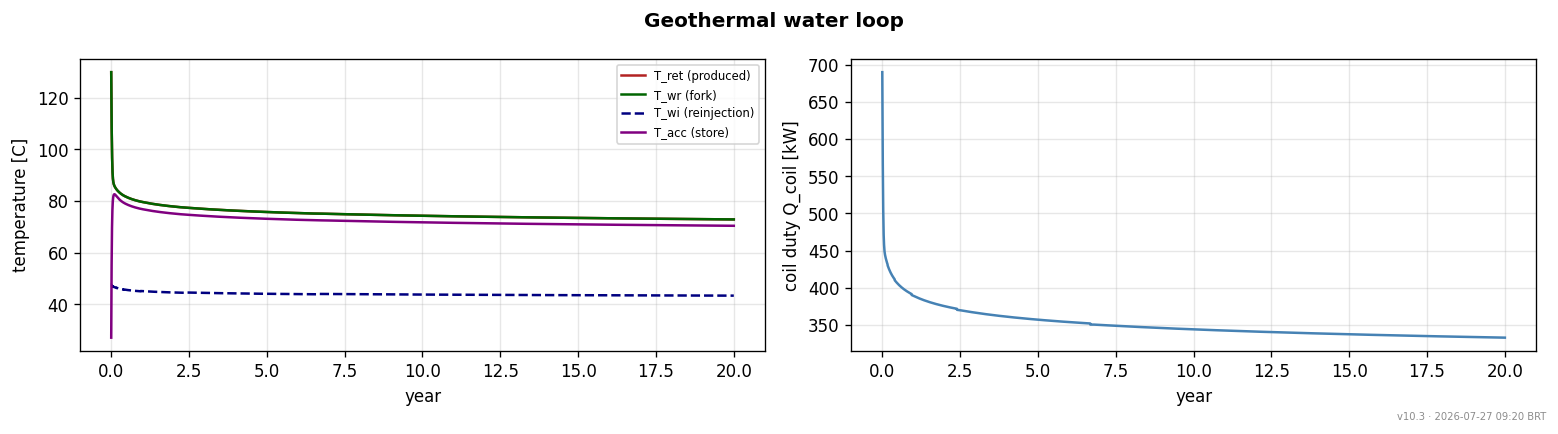

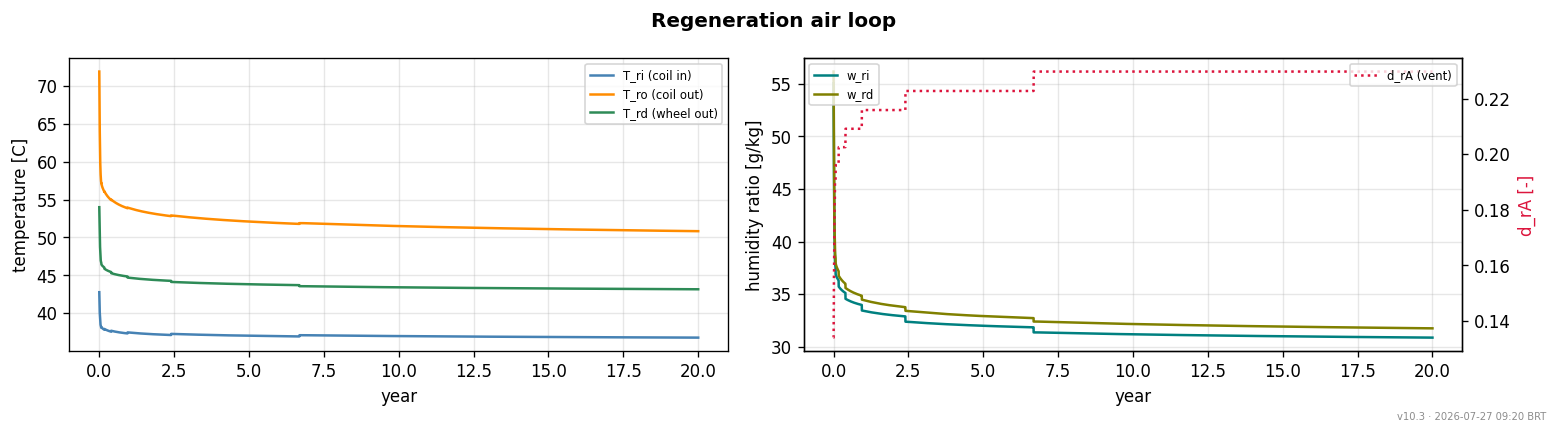

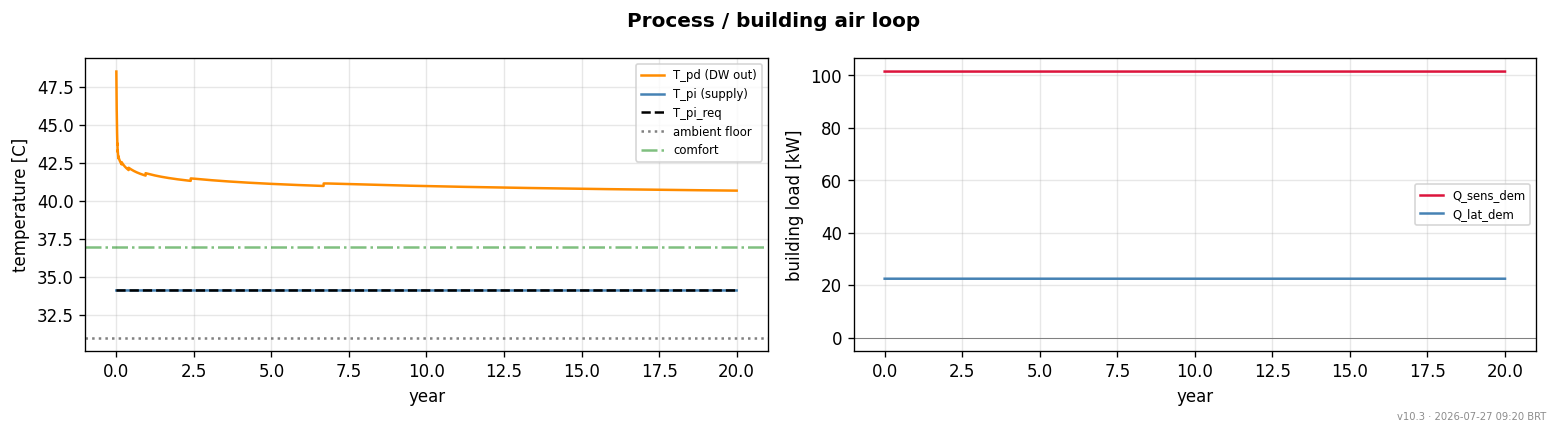

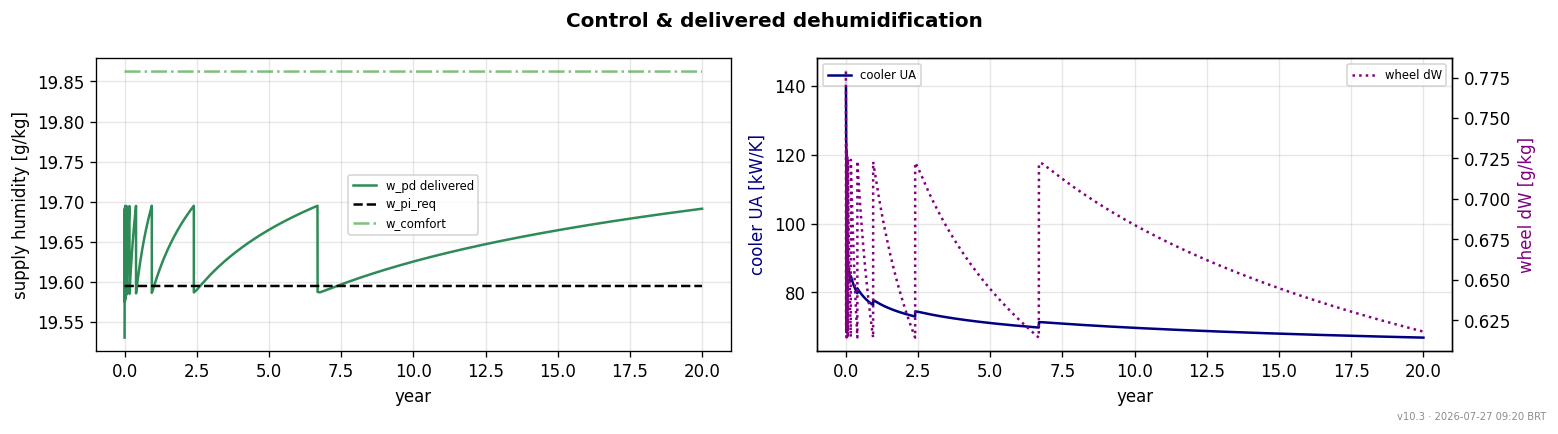

In [19]:
print("="*84)
print(f"DBHE master notebook  v{NB_VERSION}  ({NB_STAMP})")
print("="*84)
out, dbhe, acc = run_facility(Lbh_default, flow_rate_m3_h_demo, kt_demo)
print("="*84)
def rh(T,w): return 100.*(w*p_atm/(0.622+w))/p_sat(T)
i=-1; t=(np.arange(n_steps)+1)*n_days_per_step/365.25
w_pc=w_from_RH(T_pc,RH_pc); w_oa=w_from_RH(T_oa,RH_oa)

print(f"HATCHERY  N_eggs={N_eggs:,}  ->  Q_eggs_sens={Q_eggs_sens/1e3:.1f} kW, "
      f"egg moisture={mdot_evap_eggs*1000:.2f} g/s  |  supply {mdot_pro:.2f} kg/s")
print(f"DEMAND (hold {T_pc:.0f}C/{RH_pc:.0%}, ambient {T_oa:.0f}C/{RH_oa:.0%}):")
print(f"   Q_sens_dem = {out['Q_sens_dem'][i]/1e3:6.1f} kW    Q_lat_dem = {out['Q_lat_dem'][i]/1e3:6.1f} kW"
      f"   -> {'SENSIBLE-dominated' if abs(out['Q_sens_dem'][i])>abs(out['Q_lat_dem'][i]) else 'LATENT-dominated'}")
print("-"*84)
print(f"{'subsystem':<20}{'steady values (final year)':<60}")
print(f"{'water loop':<20}T_ret={out['T_ret'][i]:.1f}  T_wr={out['T_wr'][i]:.1f}  T_wi={out['T_wi'][i]:.1f}  T_acc={out['T_acc'][i]:.1f} C")
print(f"{'regen air loop':<20}T_ri={out['T_ri'][i]:.1f}  T_ro={out['T_ro'][i]:.1f}  T_rd={out['T_rd'][i]:.1f} C | "
      f"w_ri={out['w_ri'][i]*1000:.1f} w_rd={out['w_rd'][i]*1000:.1f} g/kg | d_rA={out['d_rA_ctrl'][i]:.2f}")
print(f"{'process/building':<20}T_pd={out['T_pd'][i]:.1f}->T_pi={out['T_pi'][i]:.1f} C (req {out['T_pi_req'][i]:.1f}) | "
      f"w_pd={out['w_pd'][i]*1000:.1f} g/kg (req {out['w_pi_req'][i]*1000:.1f}) | UA_cool={out['UA_cool'][i]/1e3:.1f} kW/K")
print(f"{'flags':<20}humidity {'MET' if not out['sat_hum'][i] else 'SATURATED'} | "
      f"temp {'MET' if not out['sat_cool'][i] else 'SATURATED (below ambient)'}")
print(dw_regime_report())

# ---- FIGURE 1: geothermal water loop ----
fig,ax=plt.subplots(1,2,figsize=(13,3.5)); fig.suptitle('Geothermal water loop',fontweight='bold')
ax[0].plot(t,out['T_ret'],label='T_ret (produced)',color='firebrick')
ax[0].plot(t,out['T_wr'],label='T_wr (fork)',color='darkgreen')
ax[0].plot(t,out['T_wi'],label='T_wi (reinjection)',color='navy',ls='--')
ax[0].plot(t,out['T_acc'],label='T_acc (store)',color='purple')
ax[0].set_ylabel('temperature [C]');ax[0].legend(fontsize=7);ax[0].grid(alpha=.3);ax[0].set_xlabel('year')
ax[1].plot(t,out['Q_coil']/1e3,color='steelblue')
ax[1].set_ylabel('coil duty Q_coil [kW]');ax[1].grid(alpha=.3);ax[1].set_xlabel('year')
plt.tight_layout();version_footer()
plt.show()

# ---- FIGURE 2: regeneration air loop ----
fig,ax=plt.subplots(1,2,figsize=(13,3.5)); fig.suptitle('Regeneration air loop',fontweight='bold')
ax[0].plot(t,out['T_ri'],label='T_ri (coil in)',color='steelblue')
ax[0].plot(t,out['T_ro'],label='T_ro (coil out)',color='darkorange')
ax[0].plot(t,out['T_rd'],label='T_rd (wheel out)',color='seagreen')
ax[0].set_ylabel('temperature [C]');ax[0].legend(fontsize=7);ax[0].grid(alpha=.3);ax[0].set_xlabel('year')
ax2=ax[1].twinx()
ax[1].plot(t,out['w_ri']*1000,label='w_ri',color='teal')
ax[1].plot(t,out['w_rd']*1000,label='w_rd',color='olive')
ax2.plot(t,out['d_rA_ctrl'],label='d_rA (vent)',color='crimson',ls=':')
ax[1].set_ylabel('humidity ratio [g/kg]');ax2.set_ylabel('d_rA [-]',color='crimson')
ax[1].legend(fontsize=7,loc='upper left');ax2.legend(fontsize=7,loc='upper right');ax[1].grid(alpha=.3);ax[1].set_xlabel('year')
plt.tight_layout();version_footer()
plt.show()

# ---- FIGURE 3: process / building loop ----
fig,ax=plt.subplots(1,2,figsize=(13,3.5)); fig.suptitle('Process / building air loop',fontweight='bold')
ax[0].plot(t,out['T_pd'],label='T_pd (DW out)',color='darkorange')
ax[0].plot(t,out['T_pi'],label='T_pi (supply)',color='steelblue')
ax[0].plot(t,out['T_pi_req'],label='T_pi_req',color='black',ls='--')
ax[0].axhline(T_oa,ls=':',color='gray',label='ambient floor')
ax[0].axhline(T_pc,ls='-.',color='green',label='comfort',alpha=.5)
ax[0].set_ylabel('temperature [C]');ax[0].legend(fontsize=7);ax[0].grid(alpha=.3);ax[0].set_xlabel('year')
ax[1].plot(t,out['Q_sens_dem']/1e3,label='Q_sens_dem',color='crimson')
ax[1].plot(t,out['Q_lat_dem']/1e3,label='Q_lat_dem',color='steelblue')
ax[1].axhline(0,color='gray',lw=.6)
ax[1].set_ylabel('building load [kW]');ax[1].legend(fontsize=7);ax[1].grid(alpha=.3);ax[1].set_xlabel('year')
plt.tight_layout();version_footer()
plt.show()

# ---- FIGURE 4: control & humidity delivery ----
fig,ax=plt.subplots(1,2,figsize=(13,3.5)); fig.suptitle('Control & delivered dehumidification',fontweight='bold')
ax[0].plot(t,out['w_pd']*1000,label='w_pd delivered',color='seagreen')
ax[0].plot(t,out['w_pi_req']*1000,label='w_pi_req',color='black',ls='--')
ax[0].plot(t,np.full_like(t,w_pc*1000),label='w_comfort',color='green',ls='-.',alpha=.5)
ax[0].set_ylabel('supply humidity [g/kg]');ax[0].legend(fontsize=7);ax[0].grid(alpha=.3);ax[0].set_xlabel('year')
ax2=ax[1].twinx()
ax[1].plot(t,out['UA_cool']/1e3,label='cooler UA',color='navy')
ax2.plot(t,out['dW_process']*1000,label='wheel dW',color='purple',ls=':')
ax[1].set_ylabel('cooler UA [kW/K]',color='navy');ax2.set_ylabel('wheel dW [g/kg]',color='purple')
ax[1].legend(fontsize=7,loc='upper left');ax2.legend(fontsize=7,loc='upper right');ax[1].grid(alpha=.3);ax[1].set_xlabel('year')
plt.tight_layout();version_footer()
plt.show()


## Cell 18 · Psychrometric Chart  *(state visualization)*
Plots the two air loops on a psychrometric chart at a chosen time index `k_plot`: saturation curve, constant-RH lines, and constant-enthalpy lines (dotted), with the **process/building cycle** (return → mix with outdoor → wheel → cooler → supply) and the **regeneration cycle** (coil in → coil out → wheel regen out → mix/vent) drawn as closed loops. The outdoor-air state `OA` is marked on both for reference — its position relative to the comfort state is what decides whether the building needs de- or humidification.

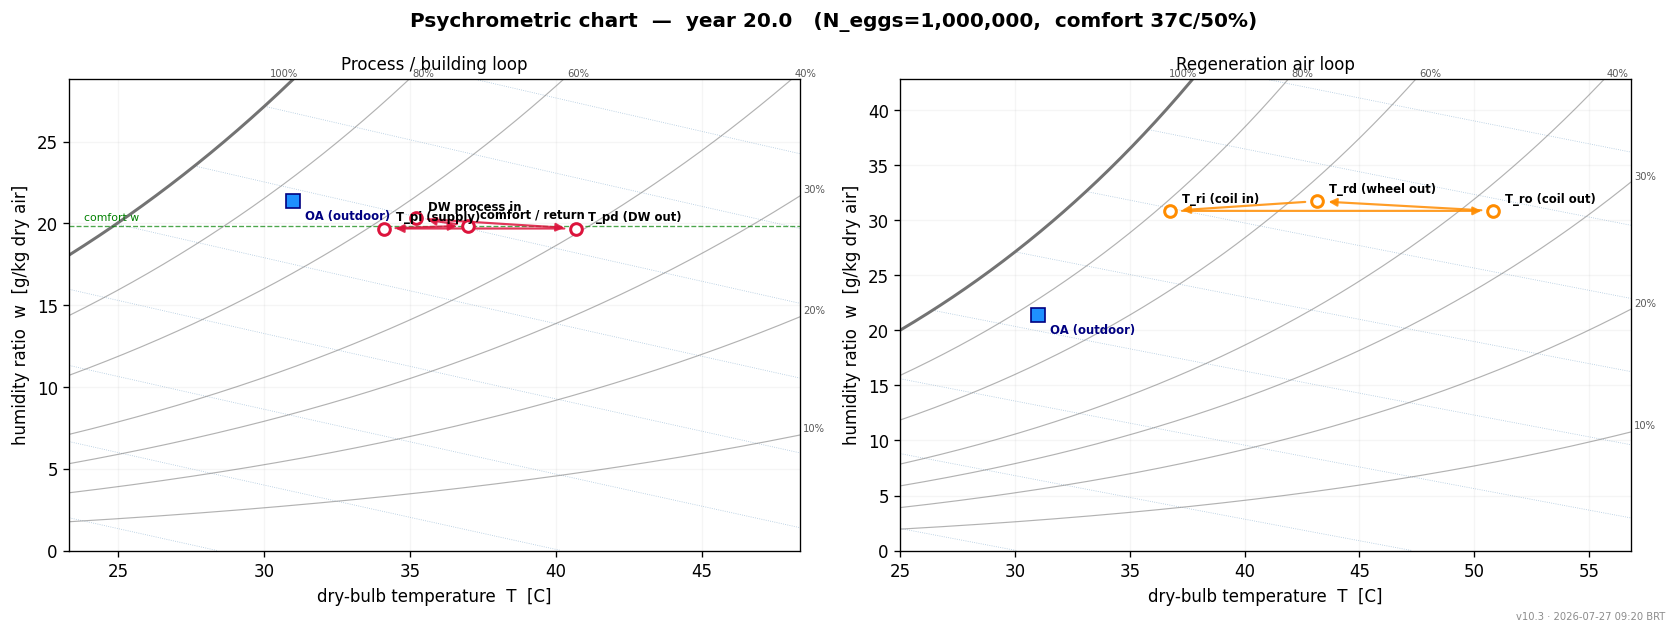

outdoor air   : 31.0 C / 75% RH  ->  w_oa = 21.36 g/kg
comfort target: 37.0 C / 50% RH  ->  w_pc = 19.86 g/kg
  w_oa - w_pc = +1.50 g/kg  ->  outdoor air is WETTER than target: ventilation ADDS moisture (dehumidification needed)
wheel process side: w_pf=20.31 -> w_pd=19.69 g/kg (DEHUMIDIFYING the process air)


In [20]:
# ---------- psychrometric chart primitives ----------
def psychro_background(ax, T_lo, T_hi, w_hi_g, rh_lines=(0.1,0.2,0.3,0.4,0.6,0.8,1.0)):
    """Saturation curve, constant-RH lines, constant-enthalpy lines (all via p_atm)."""
    T = np.linspace(T_lo, T_hi, 700)
    w_sat = w_from_RH(T, 1.0)*1000.
    for RH in rh_lines:
        w = w_from_RH(T, RH)*1000.
        m = w <= w_hi_g
        if not m.any(): continue
        ax.plot(T[m], w[m], color='0.45', lw=1.8 if RH>=1.0 else 0.7,
                alpha=1.0 if RH>=1.0 else 0.55, zorder=2)
        j = np.where(m)[0][-1]
        ax.annotate(f'{RH:.0%}', (T[j], w[j]), fontsize=6, color='0.35',
                    xytext=(-14,2) if RH>=1.0 else (2,2),
                    textcoords='offset points', zorder=2)
    for h in np.linspace(enthalpy(T_lo,0.002), enthalpy(T_hi, w_hi_g/1000.), 9):
        w_h = (h - 1.006*T)/(2501.0 + 1.86*T)*1000.
        m = (w_h >= 0) & (w_h <= w_hi_g) & (w_h <= w_sat)
        if m.sum() > 2:
            ax.plot(T[m], w_h[m], color='steelblue', lw=0.5, ls=':', alpha=0.45, zorder=1)
    ax.set_xlim(T_lo, T_hi); ax.set_ylim(0, w_hi_g)
    ax.set_xlabel('dry-bulb temperature  T  [C]')
    ax.set_ylabel('humidity ratio  w  [g/kg dry air]')
    ax.grid(alpha=0.12)

def _ranges(states, extra=()):
    Ts = [s[1] for s in states] + [e[1] for e in extra]
    ws = [s[2] for s in states] + [e[2] for e in extra]
    T_lo, T_hi = min(Ts)-6., max(Ts)+6.
    if T_hi-T_lo < 25.: c=0.5*(T_lo+T_hi); T_lo, T_hi = c-12.5, c+12.5
    return max(T_lo,0.), T_hi, max(max(ws)*1000.*1.35, 25.)

def plot_cycle(ax, states, color='crimson', close=True):
    """states = [(label, T[C], w[kg/kg]), ...]; points + process arrows."""
    pts = [(T, w*1000.) for _,T,w in states]
    seq = pts + [pts[0]] if close else pts
    for a,b in zip(seq[:-1], seq[1:]):
        ax.annotate('', xy=b, xytext=a, zorder=4,
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=1.3,
                                    alpha=0.85, shrinkA=7, shrinkB=7))
    for lab,T,w in states:
        ax.plot(T, w*1000., 'o', ms=7, mfc='white', mec=color, mew=1.8, zorder=5)
        ax.annotate(lab, (T, w*1000.), fontsize=7, fontweight='bold', zorder=6,
                    xytext=(7,5), textcoords='offset points')

# ---------- assemble the states ----------
k_plot = -1                      # time index: -1 = final year, 0 = first step
w_pc = w_from_RH(T_pc, RH_pc); w_oa = w_from_RH(T_oa, RH_oa)
T_pf, w_pf = process_inlet_state(w_pc, w_oa)      # DW process inlet (mix + fan)
OA = ('OA (outdoor)', T_oa, w_oa)

proc = [('comfort / return', T_pc, w_pc),
        ('DW process in',    T_pf, w_pf),
        ('T_pd (DW out)',    out['T_pd'][k_plot], out['w_pd'][k_plot]),
        ('T_pi (supply)',    out['T_pi'][k_plot], out['w_pi'][k_plot])]
regen = [('T_ri (coil in)',   out['T_ri'][k_plot], out['w_ri'][k_plot]),
         ('T_ro (coil out)',  out['T_ro'][k_plot], out['w_ri'][k_plot]),
         ('T_rd (wheel out)', out['T_rd'][k_plot], out['w_rd'][k_plot])]

yr = (k_plot % n_steps + 1)*n_days_per_step/365.25
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
fig.suptitle(f'Psychrometric chart  \u2014  year {yr:.1f}   '
             f'(N_eggs={N_eggs:,},  comfort {T_pc:.0f}C/{RH_pc:.0%})', fontweight='bold')

T_lo,T_hi,w_hi = _ranges(proc, extra=[OA])
psychro_background(ax[0], T_lo, T_hi, w_hi)
plot_cycle(ax[0], proc, color='crimson')
ax[0].plot(OA[1], OA[2]*1000., 's', ms=8, mfc='dodgerblue', mec='navy', zorder=6)
ax[0].annotate(OA[0], (OA[1], OA[2]*1000.), fontsize=7, fontweight='bold',
               color='navy', xytext=(7,-11), textcoords='offset points', zorder=6)
ax[0].axhline(w_pc*1000., ls='--', lw=0.8, color='green', alpha=0.7)
ax[0].annotate('comfort w', (T_lo+0.5, w_pc*1000.), fontsize=6.5, color='green',
               xytext=(0,3), textcoords='offset points')
ax[0].set_title('Process / building loop', fontsize=10)

T_lo,T_hi,w_hi = _ranges(regen, extra=[OA])
psychro_background(ax[1], T_lo, T_hi, w_hi)
plot_cycle(ax[1], regen, color='darkorange')
ax[1].plot(OA[1], OA[2]*1000., 's', ms=8, mfc='dodgerblue', mec='navy', zorder=6)
ax[1].annotate(OA[0], (OA[1], OA[2]*1000.), fontsize=7, fontweight='bold',
               color='navy', xytext=(7,-11), textcoords='offset points', zorder=6)
ax[1].set_title('Regeneration air loop', fontsize=10)
plt.tight_layout(); version_footer()
plt.show()

# ---------- what the chart says ----------
print(f"outdoor air   : {T_oa:.1f} C / {RH_oa:.0%} RH  ->  w_oa = {w_oa*1000:.2f} g/kg")
print(f"comfort target: {T_pc:.1f} C / {RH_pc:.0%} RH  ->  w_pc = {w_pc*1000:.2f} g/kg")
d = (w_oa - w_pc)*1000.
print(f"  w_oa - w_pc = {d:+.2f} g/kg  ->  outdoor air is "
      f"{'WETTER than target: ventilation ADDS moisture (dehumidification needed)' if d>0 else 'DRIER than target: ventilation REMOVES moisture (humidification needed)'}")
print(f"wheel process side: w_pf={w_pf*1000:.2f} -> w_pd={out['w_pd'][k_plot]*1000:.2f} g/kg "
      f"({'DEHUMIDIFYING' if out['w_pd'][k_plot]<w_pf else 'HUMIDIFYING'} the process air)")
